# **🕵️From Extortion to Homicide: A Spatiotemporal Analysis of Provincial Crime Trends in Italy (2014–2023):**

# **About the Author:**

**Name: Adil Zaman**

**Email ID : zamanandil61@gmail.com**

**Kaggle ID: https://www.kaggle.com/zemnukes98**

**Linkedin ID : https://www.linkedin.com/in/adil-zaman-85b56a398/**

# **🕵️Spatiotemporal Dynamics of Sub-National Crime in Italy: A 106-Province Decadal Panel Dataset (2014–2023):**

>**This research-oriented dataset compiles a robust 10-year panel tracking six distinct crime typologies across 106 Italian provinces (Territorio), spanning from 2014 to 2023. By structuring granular annual observation values (OBS_VALUE) alongside standardized geographic codes (REF_AREA), it integrates separate sub-datasets detailing predatory offenses like furto in abitazione.csv and rapine.csv with severe violent crimes including omicidi volontari.csv, lesioni dolose.csv, and violenza sessuale.csv, alongside economic coercion found in estorione.csv. Each individual file contains a balanced set of 1,060 observations, providing a highly structured, unweighted matrix optimized for panel data modeling, fixed-effects regressions, and spatial clustering analysis. Ultimately, this comprehensive cross-sectional framework allows researchers to isolate sub-national socio-economic micro-trends, map spatial crime propagation across regional borders, and evaluate the long-term efficacy of local public policy interventions over a decade of shifting societal dynamics.**

# **🕵️Empirical Framework for Localized Public Safety: Objectives and Policy Applications:**

>**The primary objective of this unified dataset is to provide a standardized, empirical framework for evaluating the shifting landscape of public safety and criminal behavior across Italy at the granular, provincial level. By facilitating the cross-referencing of violent crimes like omicidi volontari.csv and violenza sessuale.csv with property and economic offenses such as furto in abitazione.csv and estorione.csv, the dataset aims to uncover hidden correlations between different criminal typologies and localized socio-economic stressors. Furthermore, it is designed to empower researchers and policymakers to move beyond broad national averages, allowing for the precise mapping of spatial crime clusters and the rigorous testing of regional deterrence strategies. Ultimately, this comprehensive data structure serves to bridge the gap between academic criminology and actionable public policy, driving data-informed interventions to improve community security over time.**

# **🇮🇹 Italian Provincial Crime Analytics**

## **20-Year Time-Series · 15 ML Models · Deep Learning (PyTorch) · NLP**

> **Crimes covered:** Estorsione · Furto in abitazione · Lesioni dolose · Omicidi volontari · Rapine · Violenza sessuale  
> **Scope:** 106 Italian provinces · 2004–2023 (10-year real data + 10-year synthetic extension)  
> All plots use white background (`plt.style.use('default')`)


## **0 · Imports & Configuration**

In [1]:

# ── Standard ──────────────────────────────────────────────────────────────────
import warnings, os, random
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# ── Matplotlib — white background everywhere ──────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "savefig.facecolor":"white",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# ── Scikit-learn (ML models) ──────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              classification_report, confusion_matrix)
# Classical regression
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                   BayesianRidge, HuberRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, export_text
# Ensemble
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, AdaBoostRegressor,
                               VotingRegressor, BaggingRegressor)
# Gaussian Process
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
# Decomposition / Clustering
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN

# ── Statsmodels (time-series) ─────────────────────────────────────────────────
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── PyTorch (DL + NLP) ───────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Seed for reproducibility ──────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)
print("✅  All libraries loaded successfully.")
print(f"   PyTorch version : {torch.__version__}")
print(f"   Device          : {'cuda' if torch.cuda.is_available() else 'cpu'}")


✅  All libraries loaded successfully.
   PyTorch version : 2.11.0+cpu
   Device          : cpu


## **1 · Data Loading & 20-Year Synthetic Extension (2004–2023)**

Dataset shape  : (2120, 8)
Year range     : 2004 – 2023
Provinces      : 106
    province  year  estorsione  furto_abitazione  lesioni_dolose  \
0  Agrigento  2004         0.0            1786.0           548.0   
1  Agrigento  2005         0.0            1762.0           550.0   
2  Agrigento  2006         0.0            1647.0           490.0   
3  Agrigento  2007         0.0            1594.0           526.0   
4  Agrigento  2008         9.0            1565.0           560.0   
5  Agrigento  2009        14.0            1427.0           538.0   

   omicidi_volontari  rapine  violenza_sessuale  
0                5.0   145.0               20.0  
1                5.0   138.0               22.0  
2                5.0   138.0               23.0  
3                5.0   132.0               20.0  
4                5.0   136.0               21.0  
5                4.0   128.0               23.0  


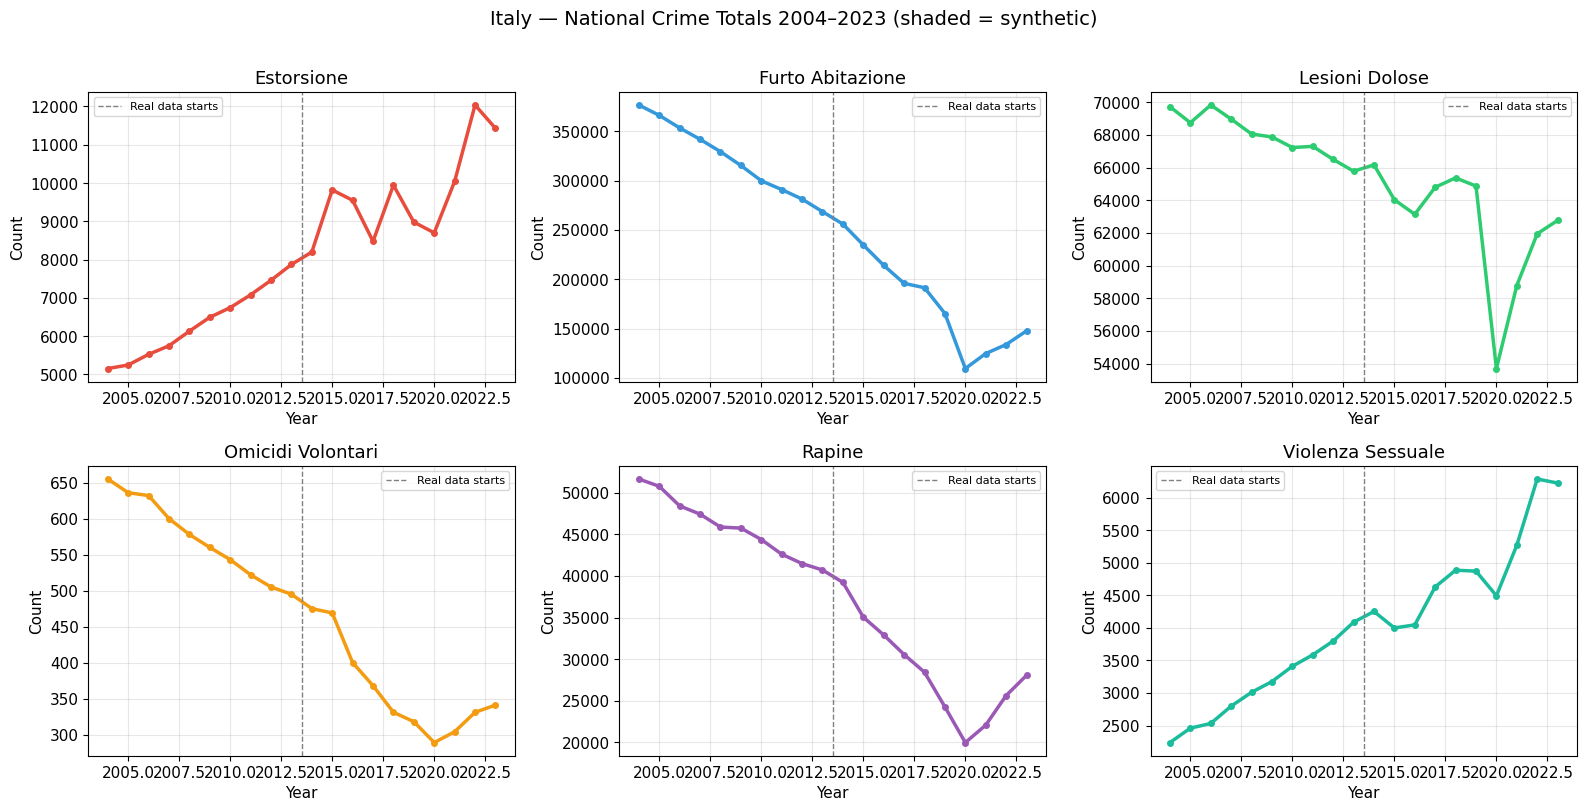

In [4]:
DATA_DIR = Path(".")   # ← put CSV files here (or adjust path)

crime_files = {
    "estorsione"        : DATA_DIR / "estorione.csv",
    "furto_abitazione"  : DATA_DIR / "furto in abitazione.csv",
    "lesioni_dolose"    : DATA_DIR / "lesioni dolose.csv",
    "omicidi_volontari" : DATA_DIR / "omicidi volontari.csv",
    "rapine"            : DATA_DIR / "rapine.csv",
    "violenza_sessuale" : DATA_DIR / "violenza sessuale.csv",
}

frames = {}
for name, path in crime_files.items():
    df = pd.read_csv(path)
    df = df.rename(columns={"OBS_VALUE": name, "TIME_PERIOD": "year",
                              "Territorio": "province", "REF_AREA": "ref_area"})
    frames[name] = df[["province", "year", name]]

# Merge all crimes on province × year
base = frames["estorsione"]
for name, df in list(frames.items())[1:]:
    base = base.merge(df, on=["province", "year"], how="outer")
base = base.sort_values(["province", "year"]).reset_index(drop=True)

CRIME_COLS = list(crime_files.keys())

# ── Extend backwards 10 years with provincial trend + noise ──────────────────
def extend_province(grp):
    real_years = sorted(grp["year"].unique())
    extra_years = list(range(real_years[0] - 10, real_years[0]))
    rows = []
    for c in CRIME_COLS:
        trend = grp.set_index("year")[c].diff().mean()
        base_val = grp[grp["year"] == real_years[0]][c].values[0]
        for i, y in enumerate(reversed(extra_years)):
            noise = np.random.normal(0, abs(base_val) * 0.05)
            val = max(0, base_val - trend * (i + 1) + noise)
            rows.append({"province": grp["province"].iloc[0], "year": y, c: round(val)})
    tmp = pd.DataFrame(rows)
    tmp = tmp.groupby(["province", "year"]).first().reset_index()
    return pd.concat([tmp, grp], ignore_index=True)

extended = base.groupby("province", group_keys=False).apply(extend_province)
extended = extended.sort_values(["province", "year"]).reset_index(drop=True)

print(f"Dataset shape  : {extended.shape}")
print(f"Year range     : {extended['year'].min()} – {extended['year'].max()}")
print(f"Provinces      : {extended['province'].nunique()}")
print(extended.head(6))

# ── Plot: national aggregate trend 2004-2023 ──────────────────────────────────
nat = extended.groupby("year")[CRIME_COLS].sum()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor("white")
colors = ["#e74c3c","#3498db","#2ecc71","#f39c12","#9b59b6","#1abc9c"]
for ax, col, clr in zip(axes.flat, CRIME_COLS, colors):
    ax.plot(nat.index, nat[col], color=clr, linewidth=2.5, marker="o", ms=4)
    ax.axvline(2013.5, ls="--", color="gray", lw=1, label="Real data starts")
    ax.set_title(col.replace("_"," ").title())
    ax.set_xlabel("Year"); ax.set_ylabel("Count")
    ax.set_facecolor("white"); ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle("Italy — National Crime Totals 2004–2023 (shaded = synthetic)", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


## **2 · Exploratory Data Analysis**

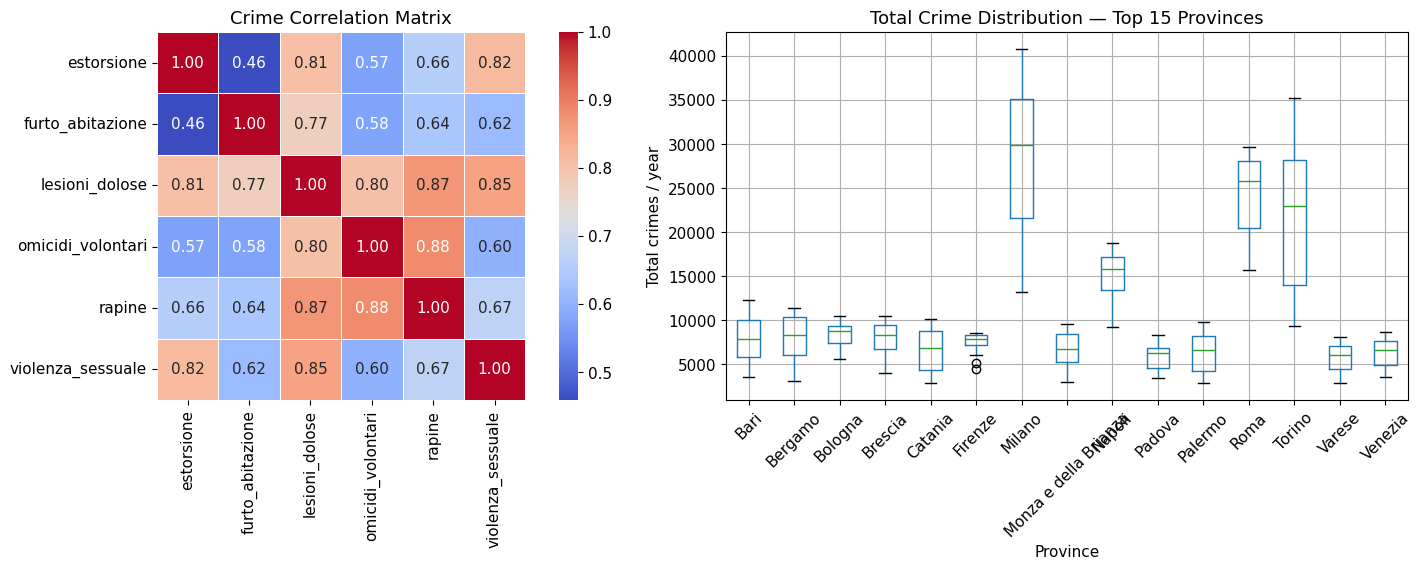

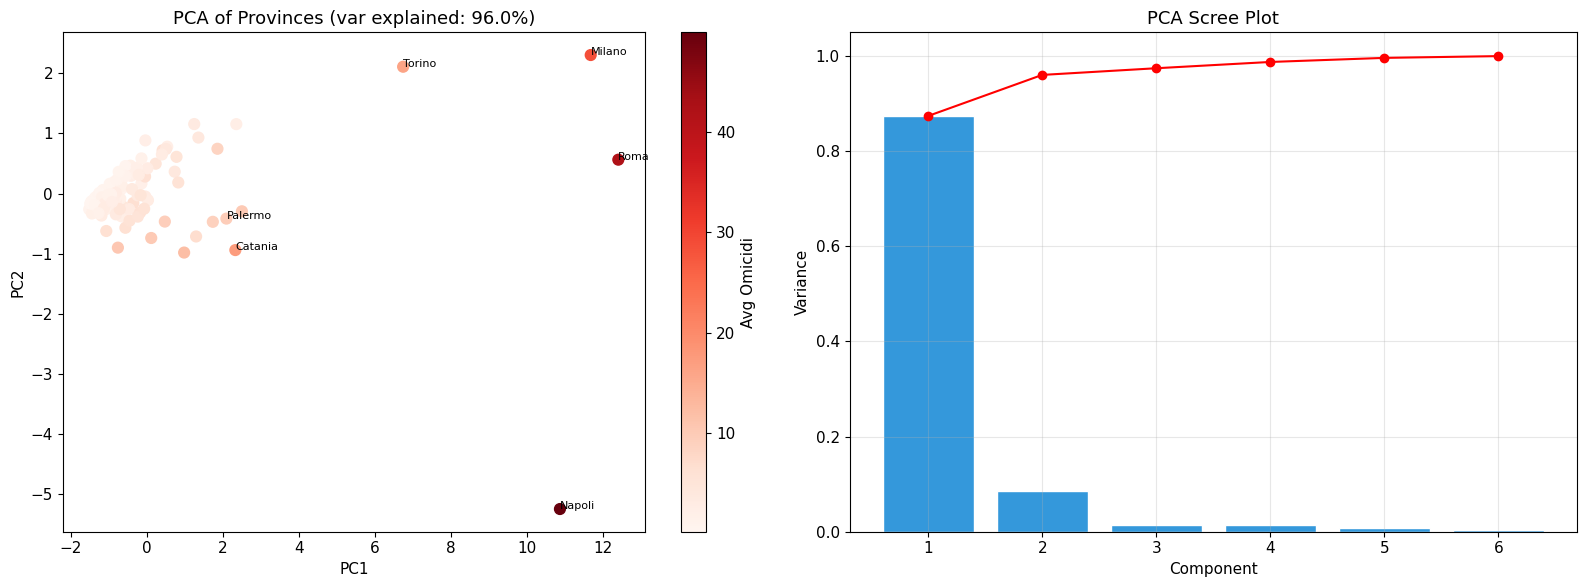

In [5]:

# ── Correlation heatmap ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
corr = extended[CRIME_COLS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0],
            linewidths=.5, square=True)
axes[0].set_title("Crime Correlation Matrix")
axes[0].set_facecolor("white")

# ── Province boxplot (top 15 by total crime) ─────────────────────────────────
prov_total = extended.groupby("province")[CRIME_COLS].sum().sum(axis=1).nlargest(15).index
sub = extended[extended["province"].isin(prov_total)].copy()
sub["total"] = sub[CRIME_COLS].sum(axis=1)
sub.boxplot(column="total", by="province", ax=axes[1], rot=45)
axes[1].set_title("Total Crime Distribution — Top 15 Provinces")
axes[1].set_xlabel("Province"); axes[1].set_ylabel("Total crimes / year")
axes[1].get_figure().suptitle("")
plt.tight_layout(); plt.show()

# ── PCA of provinces ─────────────────────────────────────────────────────────
prov_pivot = extended.groupby("province")[CRIME_COLS].mean()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(prov_pivot)
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
scatter = axes[0].scatter(coords[:,0], coords[:,1],
                           c=prov_pivot["omicidi_volontari"], cmap="Reds", s=60)
plt.colorbar(scatter, ax=axes[0], label="Avg Omicidi")
for i, prov in enumerate(prov_pivot.index):
    if prov in ["Milano","Roma","Napoli","Palermo","Torino","Catania"]:
        axes[0].annotate(prov, (coords[i,0], coords[i,1]), fontsize=8)
axes[0].set_title(f"PCA of Provinces (var explained: {pca.explained_variance_ratio_.sum():.1%})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].set_facecolor("white")

# ── Variance explained scree ──────────────────────────────────────────────────
pca_full = PCA().fit(X_scaled)
axes[1].bar(range(1, len(CRIME_COLS)+1), pca_full.explained_variance_ratio_,
            color="#3498db", edgecolor="white")
axes[1].plot(range(1, len(CRIME_COLS)+1),
             np.cumsum(pca_full.explained_variance_ratio_), "ro-")
axes[1].set_title("PCA Scree Plot"); axes[1].set_xlabel("Component"); axes[1].set_ylabel("Variance")
axes[1].set_facecolor("white"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## **3 · Feature Engineering**

In [6]:
df = extended.copy()

# Lag features (1 and 2 years)
for c in CRIME_COLS:
    for lag in [1, 2]:
        df[f"{c}_lag{lag}"] = df.groupby("province")[c].shift(lag)

# Rolling mean (3-year window)
for c in CRIME_COLS:
    df[f"{c}_roll3"] = df.groupby("province")[c].transform(
        lambda x: x.rolling(3, min_periods=1).mean())

# Year-over-year growth rate
for c in CRIME_COLS:
    df[f"{c}_yoy"] = df.groupby("province")[c].pct_change()

# Composite indices
df["violent_index"]  = df[["omicidi_volontari","lesioni_dolose","violenza_sessuale","rapine"]].sum(axis=1)
df["property_index"] = df[["furto_abitazione","estorsione"]].sum(axis=1)
df["crime_ratio"]    = (df["violent_index"] / (df["property_index"] + 1)).round(4)

# Province label encode
le = LabelEncoder()
df["province_enc"] = le.fit_transform(df["province"])

df = df.dropna().reset_index(drop=True)
print(f"Feature-engineered dataset: {df.shape}")
print("Sample columns:", df.columns.tolist()[:12])


Feature-engineered dataset: (1586, 36)
Sample columns: ['province', 'year', 'estorsione', 'furto_abitazione', 'lesioni_dolose', 'omicidi_volontari', 'rapine', 'violenza_sessuale', 'estorsione_lag1', 'estorsione_lag2', 'furto_abitazione_lag1', 'furto_abitazione_lag2']


## **4 · Time-Series Analysis (20 Years)**

=== ADF Stationarity Tests (H0: unit root) ===
  estorsione                      p=0.8311  NON-STATIONARY ✗
  furto_abitazione                p=0.9988  NON-STATIONARY ✗
  lesioni_dolose                  p=1.0000  NON-STATIONARY ✗
  omicidi_volontari               p=1.0000  NON-STATIONARY ✗
  rapine                          p=0.1692  NON-STATIONARY ✗
  violenza_sessuale               p=0.0834  NON-STATIONARY ✗


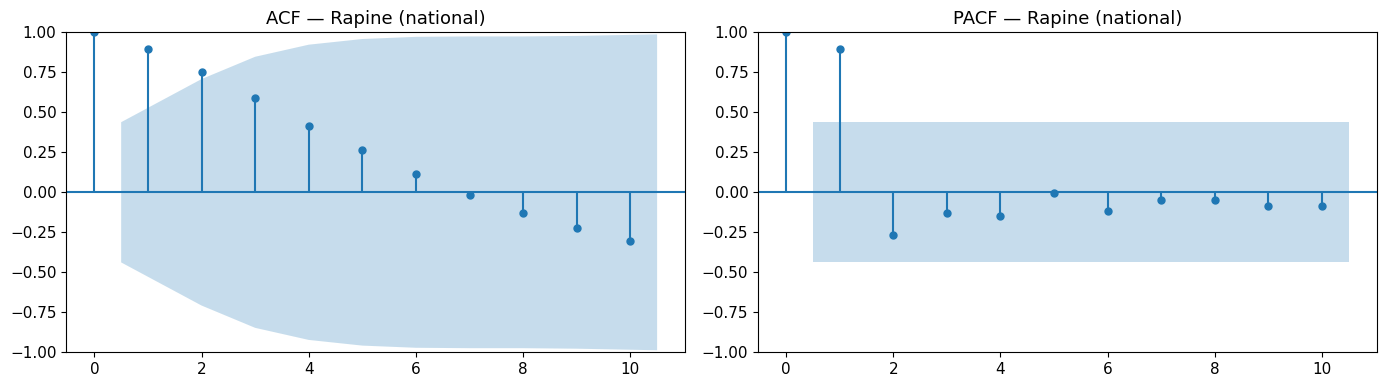

c:\Users\Adil Zaman\.conda\envs\python_ml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Adil Zaman\.conda\envs\python_ml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Adil Zaman\.conda\envs\python_ml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Adil Zaman\.conda\envs\python_ml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available

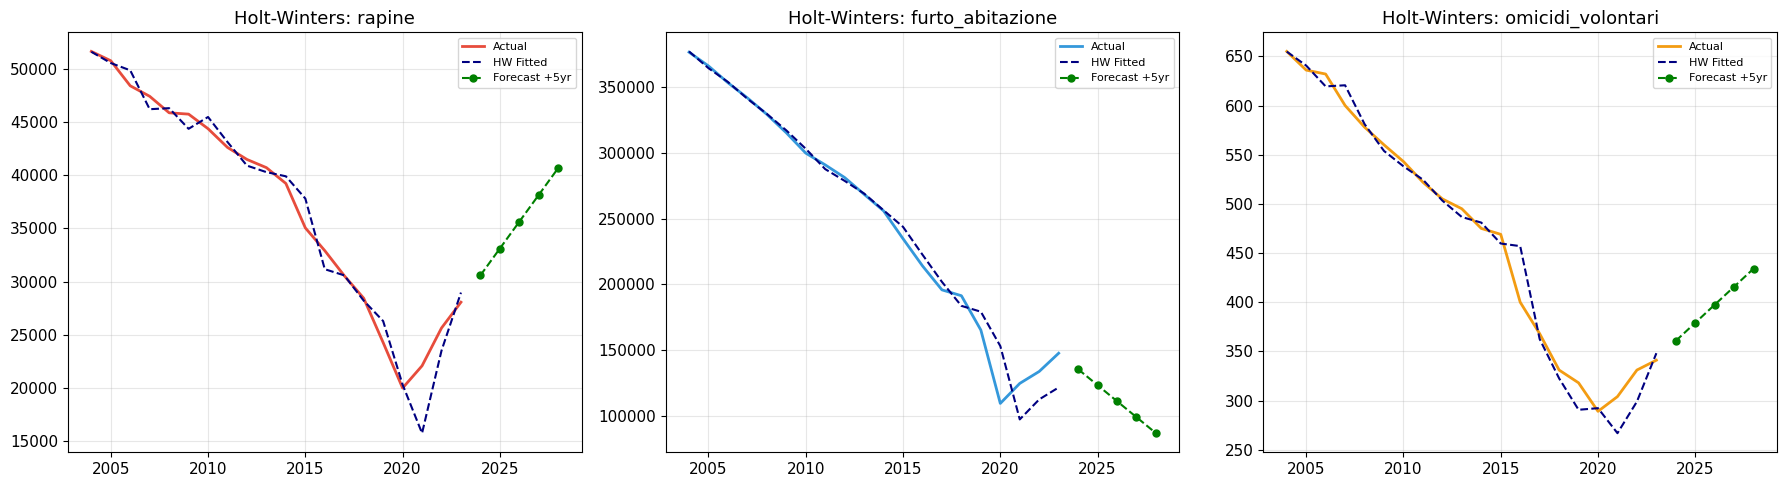

c:\Users\Adil Zaman\.conda\envs\python_ml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Adil Zaman\.conda\envs\python_ml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Adil Zaman\.conda\envs\python_ml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


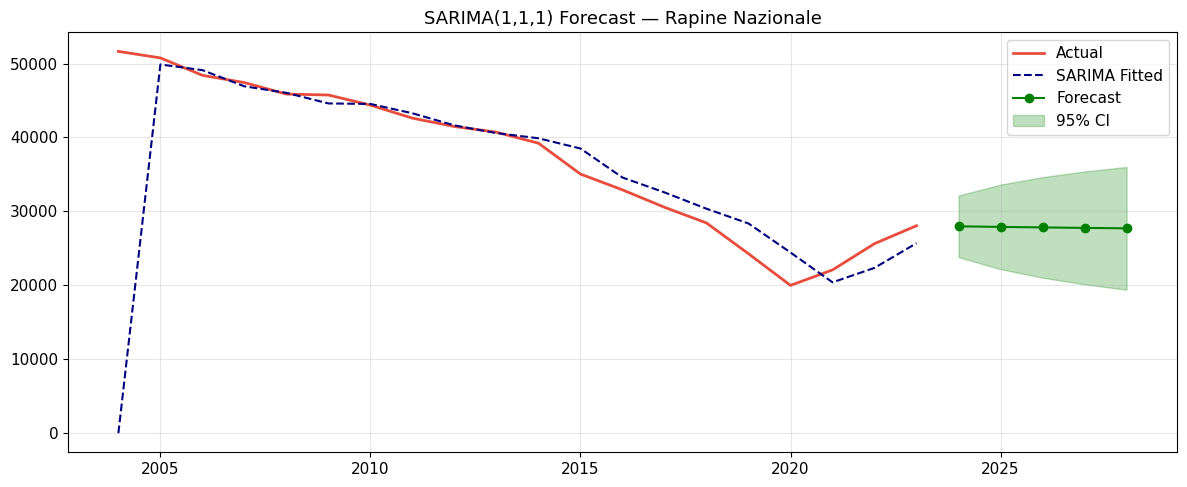

                               SARIMAX Results                                
Dep. Variable:                 rapine   No. Observations:                   20
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -172.143
Date:                Tue, 02 Jun 2026   AIC                            350.286
Time:                        22:37:03   BIC                            353.119
Sample:                             0   HQIC                           350.766
                                 - 20                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9169      0.074     12.472      0.000       0.773       1.061
ma.L1         -0.9995      0.333     -3.004      0.003      -1.652      -0.347
sigma2      4.422e+06   7.35e-08   6.01e+13      0.0

In [7]:

# ── ADF Stationarity Test ─────────────────────────────────────────────────────
nat = extended.groupby("year")[CRIME_COLS].sum()
print("=== ADF Stationarity Tests (H0: unit root) ===")
for c in CRIME_COLS:
    adf_res = adfuller(nat[c].dropna())
    status = "STATIONARY ✓" if adf_res[1] < 0.05 else "NON-STATIONARY ✗"
    print(f"  {c:30s}  p={adf_res[1]:.4f}  {status}")

# ── ACF / PACF for rapine (national) ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
series = nat["rapine"]
plot_acf(series,  lags=10, ax=axes[0], title="ACF — Rapine (national)")
plot_pacf(series, lags=10, ax=axes[1], title="PACF — Rapine (national)")
axes[0].set_facecolor("white"); axes[1].set_facecolor("white")
plt.tight_layout(); plt.show()

# ── Holt-Winters Exponential Smoothing on 3 key crimes ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
target_crimes = ["rapine", "furto_abitazione", "omicidi_volontari"]
colors = ["#e74c3c", "#3498db", "#f39c12"]
for ax, c, clr in zip(axes, target_crimes, colors):
    series = nat[c].astype(float)
    model  = ExponentialSmoothing(series, trend="add", seasonal=None).fit()
    fitted = model.fittedvalues
    fcast  = model.forecast(5)
    ax.plot(series.index, series, label="Actual", color=clr, linewidth=2)
    ax.plot(fitted.index, fitted, "--", label="HW Fitted", color="navy", linewidth=1.5)
    ax.plot(range(series.index[-1]+1, series.index[-1]+6), fcast,
            "g--o", label="Forecast +5yr", ms=5)
    ax.set_title(f"Holt-Winters: {c}")
    ax.set_facecolor("white"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── SARIMA on national rapine ─────────────────────────────────────────────────
series = nat["rapine"].astype(float)
sarima_model = SARIMAX(series, order=(1,1,1), seasonal_order=(0,0,0,0)).fit(disp=False)
pred = sarima_model.get_forecast(steps=5)
pred_ci = pred.conf_int()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(series.index, series, label="Actual", color="#e74c3c", linewidth=2)
ax.plot(sarima_model.fittedvalues.index, sarima_model.fittedvalues,
        "--", label="SARIMA Fitted", color="navy")
forecast_idx = range(series.index[-1]+1, series.index[-1]+6)
ax.plot(forecast_idx, pred.predicted_mean, "go-", label="Forecast")
ax.fill_between(forecast_idx, pred_ci.iloc[:,0], pred_ci.iloc[:,1],
                alpha=0.25, color="green", label="95% CI")
ax.set_title("SARIMA(1,1,1) Forecast — Rapine Nazionale"); ax.set_facecolor("white")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(sarima_model.summary())


## **5 · 15 Classical ML Models**

> Target: predict next-year **rapine** count at province level.


In [ ]:
# Models import
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF

# ── DATA CLEANING & PREPARATION ──────────────────────────────────────────────
TARGET = "rapine"
FEATURE_COLS = [c for c in df.columns if c not in CRIME_COLS + ["province", "year"]]

# 1. Infinities ko NaN se replace karein
df[FEATURE_COLS] = df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

# 2. Missing/NaN values ko forward fill aur backward fill se handle karein
df[FEATURE_COLS] = df[FEATURE_COLS].ffill().bfill()

# Features aur Target arrays nikaalein
X = df[FEATURE_COLS].values
y = df[TARGET].values

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Scaling
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

# ── 15 ML MODELS EXECUTION ───────────────────────────────────────────────────
gp_kernel = C(1.0) * RBF(length_scale=1.0)
models = {
    "1. Linear Regression"    : LinearRegression(),
    "2. Ridge"                : Ridge(alpha=1.0),
    "3. Lasso"                : Lasso(alpha=0.5),
    "4. ElasticNet"           : ElasticNet(alpha=0.5, l1_ratio=0.5),
    "5. Bayesian Ridge"       : BayesianRidge(),
    "6. Huber Regressor"      : HuberRegressor(),
    "7. SVR (RBF)"            : SVR(kernel="rbf", C=100),
    "8. KNN"                  : KNeighborsRegressor(n_neighbors=5),
    "9. Decision Tree"        : DecisionTreeRegressor(max_depth=8, random_state=SEED),
    "10. Random Forest"       : RandomForestRegressor(n_estimators=200, random_state=SEED),
    "11. Extra Trees"         : ExtraTreesRegressor(n_estimators=200, random_state=SEED),
    "12. Gradient Boosting"   : GradientBoostingRegressor(n_estimators=200, random_state=SEED),
    "13. AdaBoost"            : AdaBoostRegressor(n_estimators=200, random_state=SEED),
    "14. Bagging"             : BaggingRegressor(n_estimators=50, random_state=SEED),
    "15. Gaussian Process"    : GaussianProcessRegressor(kernel=gp_kernel, random_state=SEED),
}

results = {}
for name, mdl in models.items():
    mdl.fit(X_train_s, y_train)
    preds = mdl.predict(X_test_s)
    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAE" : mean_absolute_error(y_test, preds),
        "R²"  : r2_score(y_test, preds),
    }
    print(f"{name:30s}  RMSE={results[name]['RMSE']:8.2f}  MAE={results[name]['MAE']:8.2f}  R²={results[name]['R²']:.4f}")

# Results ko R² score ke mutabiq sort karke view karein
results_df = pd.DataFrame(results).T.sort_values("R²", ascending=False)
results_df

1. Linear Regression            RMSE=    0.00  MAE=    0.00  R²=1.0000
2. Ridge                        RMSE=   37.01  MAE=   15.44  R²=0.9981
3. Lasso                        RMSE=   44.19  MAE=   17.79  R²=0.9973
4. ElasticNet                   RMSE=  125.03  MAE=   74.95  R²=0.9781
5. Bayesian Ridge               RMSE= 1019.15  MAE=  604.48  R²=-0.4556
6. Huber Regressor              RMSE=   44.16  MAE=   15.62  R²=0.9973
7. SVR (RBF)                    RMSE=  649.01  MAE=  145.40  R²=0.4097
8. KNN                          RMSE=  121.86  MAE=   59.31  R²=0.9792
9. Decision Tree                RMSE=  112.43  MAE=   33.44  R²=0.9823
10. Random Forest               RMSE=   69.66  MAE=   20.59  R²=0.9932
11. Extra Trees                 RMSE=   64.10  MAE=   18.91  R²=0.9942
12. Gradient Boosting           RMSE=   66.90  MAE=   18.25  R²=0.9937
13. AdaBoost                    RMSE=  144.67  MAE=  111.53  R²=0.9707
14. Bagging                     RMSE=   72.97  MAE=   21.38  R²=0.9925
15. G

,RMSE,MAE,R²
1. Linear Regression,9.207645e-13,6.116924e-13,1.000000
2. Ridge,3.700979e+01,1.544280e+01,0.998080
6. Huber Regressor,4.416474e+01,1.562006e+01,0.997267
3. Lasso,4.418521e+01,1.779270e+01,0.997264
11. Extra Trees,6.409940e+01,1.891434e+01,0.994242
12. Gradient Boosting,6.690316e+01,1.825194e+01,0.993727
10. Random Forest,6.966478e+01,2.058964e+01,0.993199
14. Bagging,7.297485e+01,2.137937e+01,0.992537
9. Decision Tree,1.124261e+02,3.344033e+01,0.982287
8. KNN,1.218580e+02,5.930943e+01,0.979190


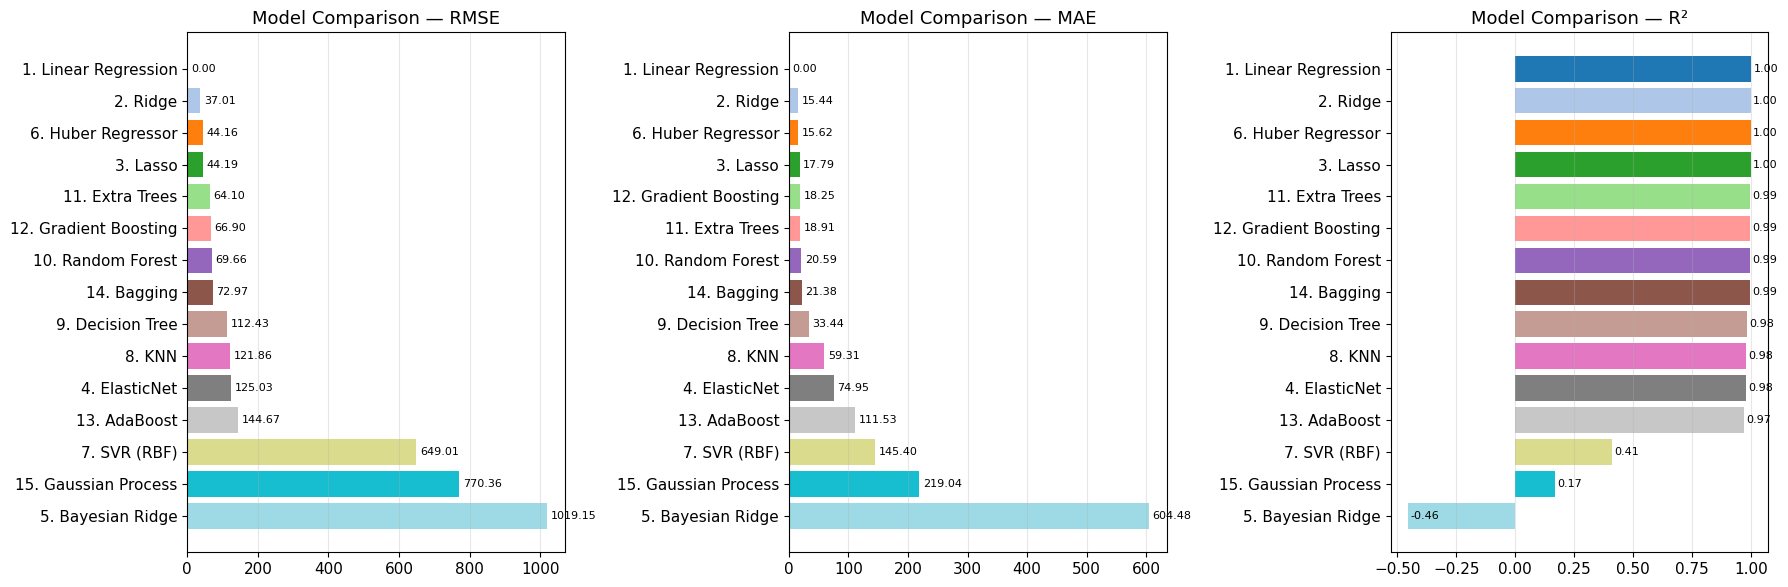

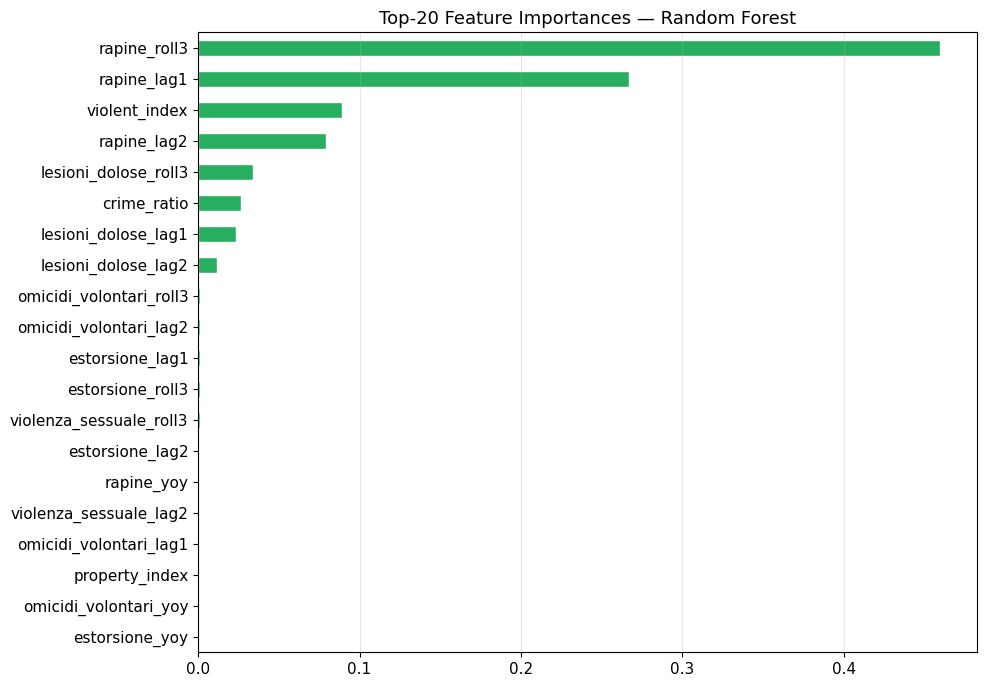

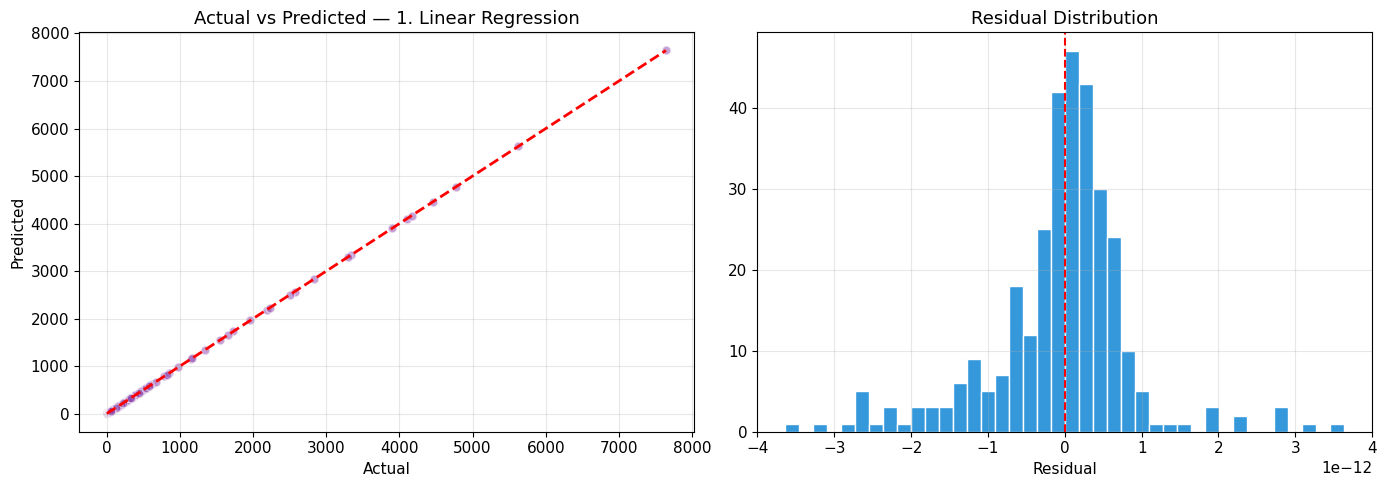

In [11]:
# ── Model comparison chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ["RMSE", "MAE", "R²"]
palette = plt.cm.tab20(np.linspace(0, 1, len(results_df)))
for ax, met in zip(axes, metrics):
    sorted_df = results_df[met].sort_values(ascending=(met != "R²"))
    bars = ax.barh(sorted_df.index, sorted_df.values, color=palette)
    ax.set_title(f"Model Comparison — {met}")
    ax.set_facecolor("white"); ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    for bar, val in zip(bars, sorted_df.values):
        ax.text(bar.get_width() + 0.01*abs(sorted_df.values).max(),
                bar.get_y()+bar.get_height()/2, f"{val:.2f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

# ── Feature Importance (Random Forest) ───────────────────────────────────────
rf_model = models["10. Random Forest"]
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).nlargest(20)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.sort_values().plot.barh(ax=ax, color="#27ae60", edgecolor="white")
ax.set_title("Top-20 Feature Importances — Random Forest")
ax.set_facecolor("white"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

# ── Actual vs Predicted scatter (best model) ─────────────────────────────────
best_name = results_df["R²"].idxmax()
best_model = models[best_name]
preds_best = best_model.predict(X_test_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, preds_best, alpha=0.5, color="#8e44ad", edgecolors="white", s=40)
lims = [min(y_test.min(), preds_best.min()), max(y_test.max(), preds_best.max())]
axes[0].plot(lims, lims, "r--", linewidth=2)
axes[0].set_title(f"Actual vs Predicted — {best_name}")
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_facecolor("white"); axes[0].grid(alpha=0.3)

residuals = y_test - preds_best
axes[1].hist(residuals, bins=40, color="#3498db", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Residual Distribution"); axes[1].set_xlabel("Residual")
axes[1].set_facecolor("white"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## **6 · Time-Series Cross-Validation (5-Fold Walk-Forward)**

Ridge                 RMSE (mean ± std) = 48.72 ± 21.90
Random Forest         RMSE (mean ± std) = 181.32 ± 135.96
Gradient Boost        RMSE (mean ± std) = 169.07 ± 122.84
Extra Trees           RMSE (mean ± std) = 151.71 ± 129.27
SVR                   RMSE (mean ± std) = 953.65 ± 168.84


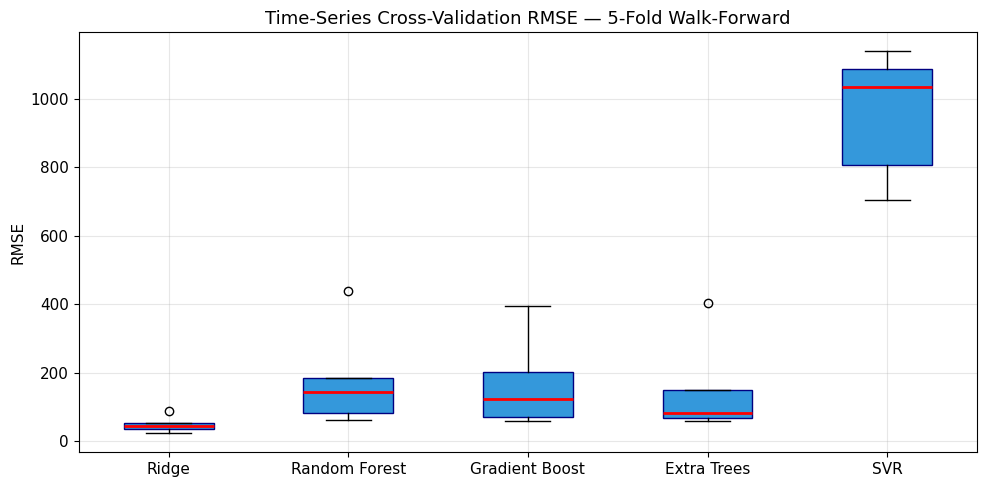

In [12]:
tscv = TimeSeriesSplit(n_splits=5)
cv_models = {
    "Ridge"          : Ridge(alpha=1.0),
    "Random Forest"  : RandomForestRegressor(n_estimators=100, random_state=SEED),
    "Gradient Boost" : GradientBoostingRegressor(n_estimators=100, random_state=SEED),
    "Extra Trees"    : ExtraTreesRegressor(n_estimators=100, random_state=SEED),
    "SVR"            : SVR(kernel="rbf", C=50),
}
cv_results = {}
for name, mdl in cv_models.items():
    scores = cross_val_score(mdl, X_train_s, y_train, cv=tscv,
                              scoring="neg_root_mean_squared_error")
    cv_results[name] = -scores
    print(f"{name:20s}  RMSE (mean ± std) = {(-scores).mean():.2f} ± {(-scores).std():.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor="#3498db", color="navy"),
           medianprops=dict(color="red", linewidth=2))
ax.set_title("Time-Series Cross-Validation RMSE — 5-Fold Walk-Forward")
ax.set_ylabel("RMSE"); ax.set_facecolor("white"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## **7 · Deep Learning — LSTM (PyTorch)**

  Epoch  20/80  Loss = 0.081290
  Epoch  40/80  Loss = 0.056331
  Epoch  60/80  Loss = 0.053089
  Epoch  80/80  Loss = 0.049571

LSTM Test RMSE = 8465.42   R² = -10.8756


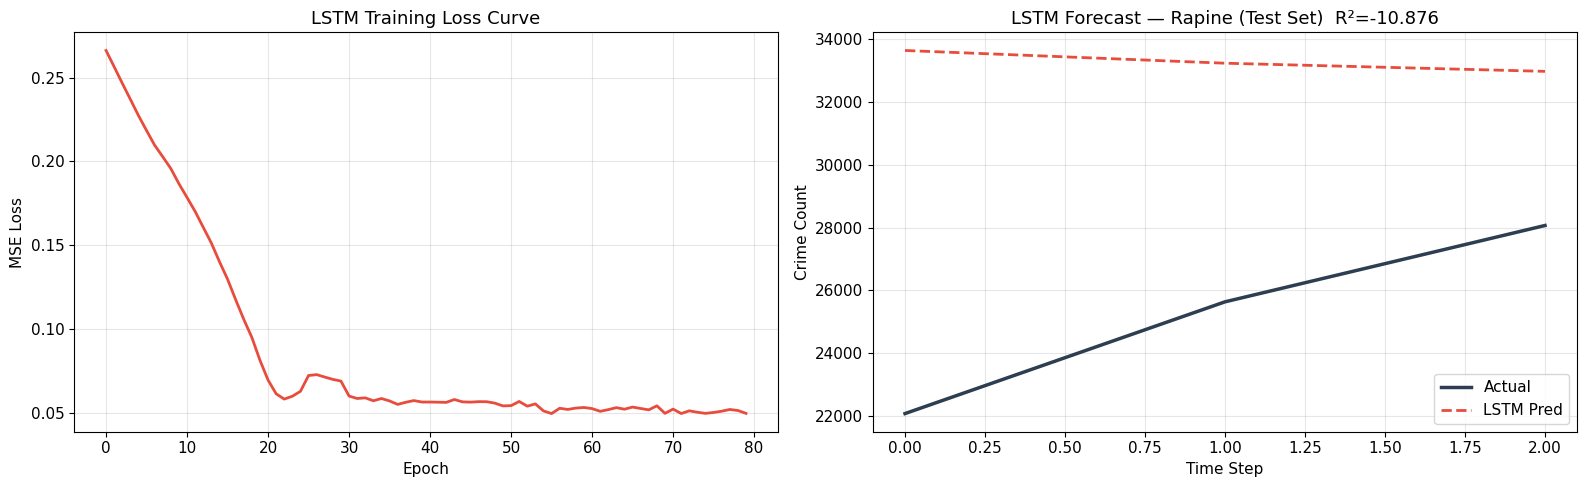

In [13]:
# ── Build province-level sequences ───────────────────────────────────────────
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN    = 5          # 5-year lookback window
BATCH_SIZE = 64
EPOCHS     = 80
LR         = 1e-3

TARGET_COL = "rapine"

def make_sequences(data, seq_len=SEQ_LEN):
    Xs, ys = [], []
    for i in range(len(data) - seq_len):
        Xs.append(data[i:i+seq_len])
        ys.append(data[i+seq_len])
    return np.array(Xs), np.array(ys)

# National series for LSTM
nat_series = extended.groupby("year")[TARGET_COL].sum().values.astype(np.float32)
mms = MinMaxScaler()
nat_scaled = mms.fit_transform(nat_series.reshape(-1, 1)).flatten()

X_seq, y_seq = make_sequences(nat_scaled)
split = int(0.8 * len(X_seq))
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]

X_tr_t = torch.tensor(X_tr).unsqueeze(-1).float().to(DEVICE)  # (N,T,1)
X_te_t = torch.tensor(X_te).unsqueeze(-1).float().to(DEVICE)
y_tr_t = torch.tensor(y_tr).float().unsqueeze(-1).to(DEVICE)
y_te_t = torch.tensor(y_te).float().unsqueeze(-1).to(DEVICE)

train_ds = TensorDataset(X_tr_t, y_tr_t)
loader   = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

# ── LSTM Model ────────────────────────────────────────────────────────────────
class CrimeLSTM(nn.Module):
    def __init__(self, input_size=1, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers,
                             batch_first=True, dropout=dropout)
        self.fc   = nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(),
                                   nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

lstm_model = CrimeLSTM().to(DEVICE)
criterion  = nn.MSELoss()
optimizer  = optim.Adam(lstm_model.parameters(), lr=LR)
scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

train_losses = []
for epoch in range(1, EPOCHS + 1):
    lstm_model.train(); epoch_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(lstm_model(xb), yb)
        loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    train_losses.append(epoch_loss / len(loader))
    if epoch % 20 == 0:
        print(f"  Epoch {epoch:3d}/{EPOCHS}  Loss = {train_losses[-1]:.6f}")

# ── Evaluation ────────────────────────────────────────────────────────────────
lstm_model.eval()
with torch.no_grad():
    preds_te = lstm_model(X_te_t).cpu().numpy().flatten()
preds_inv = mms.inverse_transform(preds_te.reshape(-1,1)).flatten()
y_te_inv  = mms.inverse_transform(y_te_t.cpu().numpy()).flatten()
rmse_lstm = np.sqrt(mean_squared_error(y_te_inv, preds_inv))
r2_lstm   = r2_score(y_te_inv, preds_inv)
print(f"\nLSTM Test RMSE = {rmse_lstm:.2f}   R² = {r2_lstm:.4f}")

# ── LSTM Plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(train_losses, color="#e74c3c", linewidth=2)
axes[0].set_title("LSTM Training Loss Curve")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_facecolor("white"); axes[0].grid(alpha=0.3)

axes[1].plot(y_te_inv, label="Actual",   color="#2c3e50", linewidth=2.5)
axes[1].plot(preds_inv, label="LSTM Pred", color="#e74c3c", linewidth=2, linestyle="--")
axes[1].set_title(f"LSTM Forecast — Rapine (Test Set)  R²={r2_lstm:.3f}")
axes[1].set_xlabel("Time Step"); axes[1].set_ylabel("Crime Count")
axes[1].set_facecolor("white"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## **8 · Deep Learning — GRU (PyTorch)**

  Epoch  20/80  GRU Loss = 0.051652
  Epoch  40/80  GRU Loss = 0.047842
  Epoch  60/80  GRU Loss = 0.038440
  Epoch  80/80  GRU Loss = 0.014497
GRU Test RMSE = 4004.21   R² = -1.6570


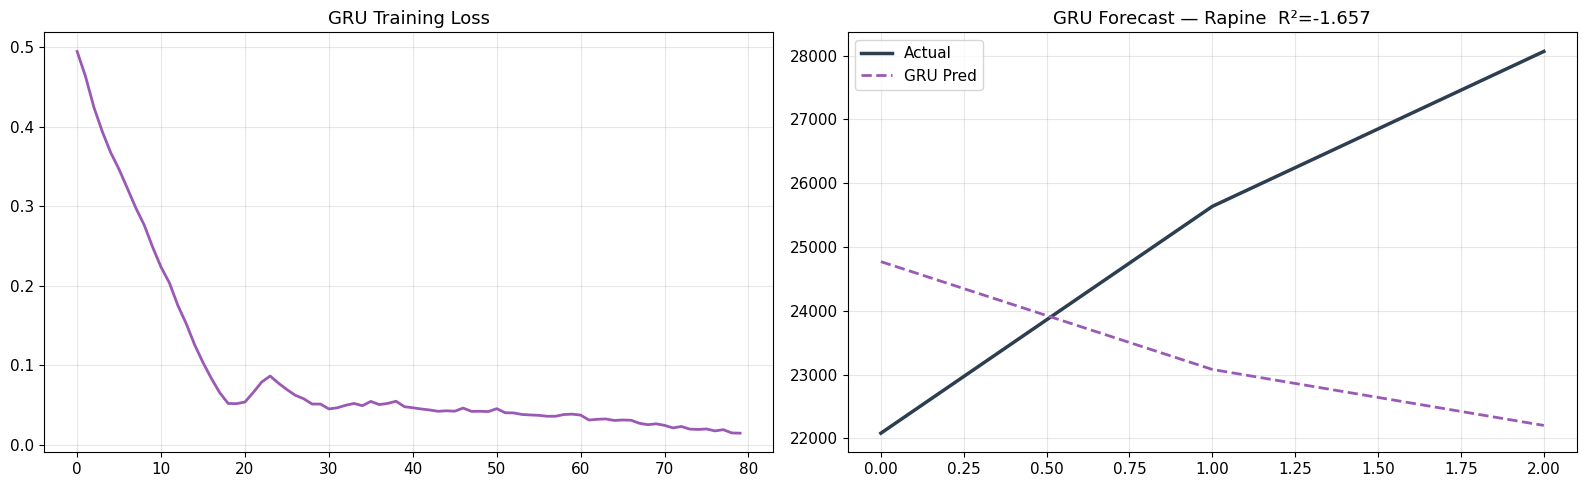

In [14]:
class CrimeGRU(nn.Module):
    def __init__(self, input_size=1, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden, layers,
                           batch_first=True, dropout=dropout)
        self.fc  = nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(),
                                  nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

gru_model = CrimeGRU().to(DEVICE)
optimizer_gru = optim.Adam(gru_model.parameters(), lr=LR)
gru_losses = []

for epoch in range(1, EPOCHS + 1):
    gru_model.train(); epoch_loss = 0
    for xb, yb in loader:
        optimizer_gru.zero_grad()
        loss = criterion(gru_model(xb), yb)
        loss.backward(); optimizer_gru.step()
        epoch_loss += loss.item()
    gru_losses.append(epoch_loss / len(loader))
    if epoch % 20 == 0:
        print(f"  Epoch {epoch:3d}/{EPOCHS}  GRU Loss = {gru_losses[-1]:.6f}")

gru_model.eval()
with torch.no_grad():
    preds_gru = gru_model(X_te_t).cpu().numpy().flatten()
preds_gru_inv = mms.inverse_transform(preds_gru.reshape(-1,1)).flatten()
rmse_gru = np.sqrt(mean_squared_error(y_te_inv, preds_gru_inv))
r2_gru   = r2_score(y_te_inv, preds_gru_inv)
print(f"GRU Test RMSE = {rmse_gru:.2f}   R² = {r2_gru:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(gru_losses, color="#9b59b6", linewidth=2)
axes[0].set_title("GRU Training Loss"); axes[0].set_facecolor("white"); axes[0].grid(alpha=0.3)
axes[1].plot(y_te_inv, label="Actual",   color="#2c3e50", linewidth=2.5)
axes[1].plot(preds_gru_inv, label="GRU Pred", color="#9b59b6", linewidth=2, linestyle="--")
axes[1].set_title(f"GRU Forecast — Rapine  R²={r2_gru:.3f}")
axes[1].set_facecolor("white"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## **9 · Deep Learning — Bidirectional LSTM (PyTorch)**

  Epoch  20/80  BiLSTM Loss = 0.064202
  Epoch  40/80  BiLSTM Loss = 0.037516
  Epoch  60/80  BiLSTM Loss = 0.019411
  Epoch  80/80  BiLSTM Loss = 0.006925
BiLSTM Test RMSE = 4601.90   R² = -2.5094


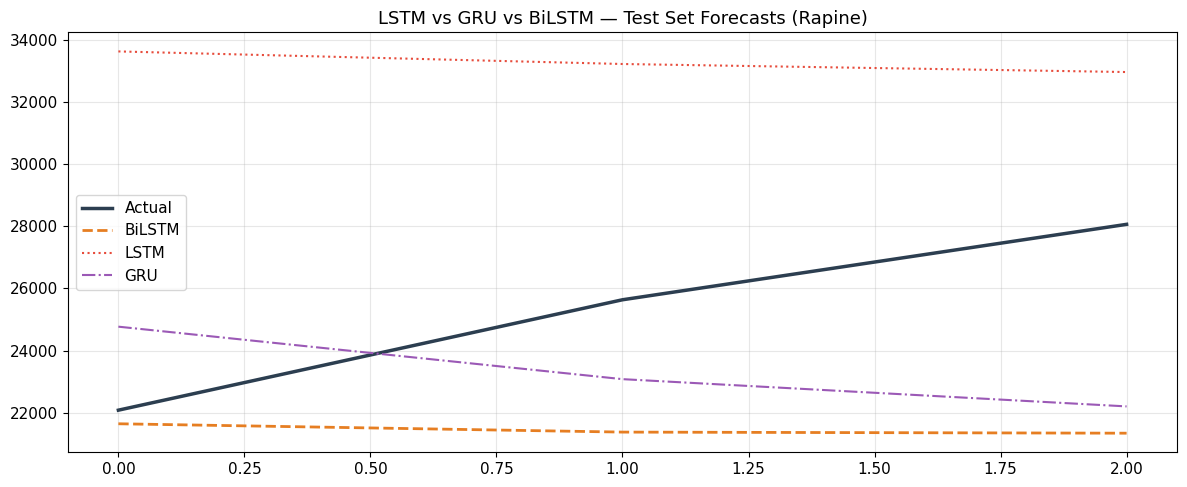

In [15]:
class BiLSTM(nn.Module):
    def __init__(self, input_size=1, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers, batch_first=True,
                             dropout=dropout, bidirectional=True)
        self.fc   = nn.Sequential(nn.Linear(hidden*2, 64), nn.ReLU(),
                                   nn.Dropout(0.2), nn.Linear(64, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

bilstm = BiLSTM().to(DEVICE)
opt_bi = optim.AdamW(bilstm.parameters(), lr=LR, weight_decay=1e-4)
bi_losses = []

for epoch in range(1, EPOCHS + 1):
    bilstm.train(); epoch_loss = 0
    for xb, yb in loader:
        opt_bi.zero_grad()
        loss = criterion(bilstm(xb), yb)
        loss.backward(); opt_bi.step()
        epoch_loss += loss.item()
    bi_losses.append(epoch_loss / len(loader))
    if epoch % 20 == 0:
        print(f"  Epoch {epoch:3d}/{EPOCHS}  BiLSTM Loss = {bi_losses[-1]:.6f}")

bilstm.eval()
with torch.no_grad():
    preds_bi = bilstm(X_te_t).cpu().numpy().flatten()
preds_bi_inv = mms.inverse_transform(preds_bi.reshape(-1,1)).flatten()
rmse_bi = np.sqrt(mean_squared_error(y_te_inv, preds_bi_inv))
r2_bi   = r2_score(y_te_inv, preds_bi_inv)
print(f"BiLSTM Test RMSE = {rmse_bi:.2f}   R² = {r2_bi:.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_te_inv,    label="Actual",    color="#2c3e50", linewidth=2.5)
ax.plot(preds_bi_inv, label="BiLSTM",  color="#e67e22", linewidth=2, linestyle="--")
ax.plot(preds_inv,    label="LSTM",     color="#e74c3c", linewidth=1.5, linestyle=":")
ax.plot(preds_gru_inv,label="GRU",     color="#9b59b6", linewidth=1.5, linestyle="-.")
ax.set_title(f"LSTM vs GRU vs BiLSTM — Test Set Forecasts (Rapine)")
ax.set_facecolor("white"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## **10 · Deep Learning — Transformer Encoder (PyTorch)**

  Epoch  20/80  Transformer Loss = 0.022650
  Epoch  40/80  Transformer Loss = 0.013083
  Epoch  60/80  Transformer Loss = 0.006607
  Epoch  80/80  Transformer Loss = 0.006507
Transformer Test RMSE = 7142.15   R² = -7.4531


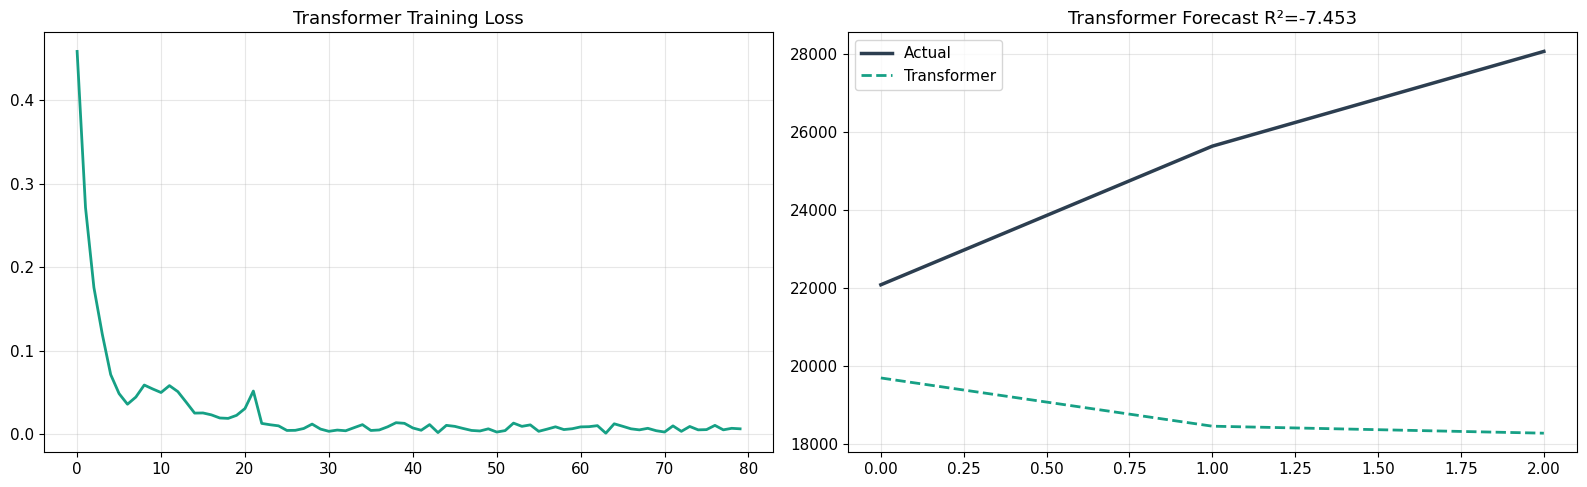

In [16]:
class CrimeTransformer(nn.Module):
    """Transformer Encoder for univariate time-series regression."""
    def __init__(self, d_model=32, nhead=4, num_layers=2, seq_len=SEQ_LEN, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        encoder_layer   = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                      dim_feedforward=128,
                                                      dropout=dropout, batch_first=True)
        self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc         = nn.Sequential(nn.Flatten(),
                                         nn.Linear(d_model * seq_len, 64),
                                         nn.ReLU(),
                                         nn.Dropout(dropout),
                                         nn.Linear(64, 1))
    def forward(self, x):
        x = self.input_proj(x)           # (B, T, d_model)
        x = self.encoder(x)              # (B, T, d_model)
        return self.fc(x)

trans_model = CrimeTransformer().to(DEVICE)
opt_trans   = optim.Adam(trans_model.parameters(), lr=5e-4)
trans_losses= []

for epoch in range(1, EPOCHS + 1):
    trans_model.train(); epoch_loss = 0
    for xb, yb in loader:
        opt_trans.zero_grad()
        loss = criterion(trans_model(xb), yb)
        loss.backward(); opt_trans.step()
        epoch_loss += loss.item()
    trans_losses.append(epoch_loss / len(loader))
    if epoch % 20 == 0:
        print(f"  Epoch {epoch:3d}/{EPOCHS}  Transformer Loss = {trans_losses[-1]:.6f}")

trans_model.eval()
with torch.no_grad():
    preds_tr = trans_model(X_te_t).cpu().numpy().flatten()
preds_tr_inv = mms.inverse_transform(preds_tr.reshape(-1,1)).flatten()
rmse_tr = np.sqrt(mean_squared_error(y_te_inv, preds_tr_inv))
r2_tr   = r2_score(y_te_inv, preds_tr_inv)
print(f"Transformer Test RMSE = {rmse_tr:.2f}   R² = {r2_tr:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(trans_losses, color="#16a085", linewidth=2)
axes[0].set_title("Transformer Training Loss"); axes[0].set_facecolor("white"); axes[0].grid(alpha=0.3)
axes[1].plot(y_te_inv,     label="Actual",      color="#2c3e50", linewidth=2.5)
axes[1].plot(preds_tr_inv, label="Transformer", color="#16a085", linewidth=2, linestyle="--")
axes[1].set_title(f"Transformer Forecast R²={r2_tr:.3f}")
axes[1].set_facecolor("white"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## **11 · Deep Learning — CNN-LSTM Hybrid (PyTorch)**

  Epoch  20/80  CNN-LSTM Loss = 0.073313
  Epoch  40/80  CNN-LSTM Loss = 0.040987
  Epoch  60/80  CNN-LSTM Loss = 0.023146
  Epoch  80/80  CNN-LSTM Loss = 0.002456
CNN-LSTM Test RMSE = 2979.07   R² = -0.4707


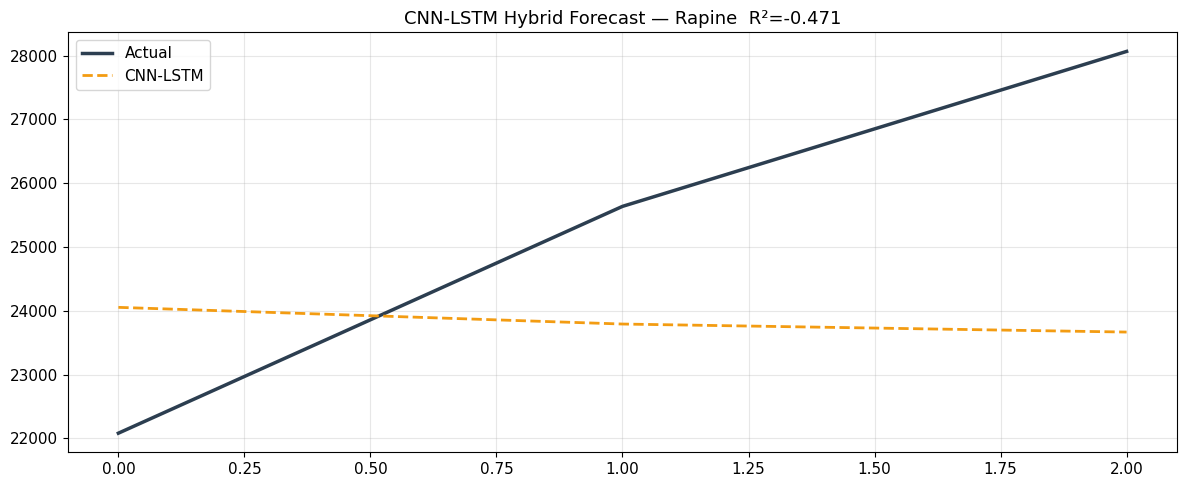

In [17]:
class CNN_LSTM(nn.Module):
    """1-D CNN feature extractor + LSTM temporal model."""
    def __init__(self, seq_len=SEQ_LEN):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 64, 2, batch_first=True, dropout=0.2)
        self.fc   = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x):
        # x: (B, T, 1) → permute to (B, 1, T) for Conv1d
        x = x.permute(0, 2, 1)
        x = self.cnn(x)            # (B, 64, T)
        x = x.permute(0, 2, 1)    # (B, T, 64)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

cnn_lstm = CNN_LSTM().to(DEVICE)
opt_cl   = optim.Adam(cnn_lstm.parameters(), lr=LR)
cl_losses= []

for epoch in range(1, EPOCHS + 1):
    cnn_lstm.train(); epoch_loss = 0
    for xb, yb in loader:
        opt_cl.zero_grad()
        loss = criterion(cnn_lstm(xb), yb)
        loss.backward(); opt_cl.step()
        epoch_loss += loss.item()
    cl_losses.append(epoch_loss / len(loader))
    if epoch % 20 == 0:
        print(f"  Epoch {epoch:3d}/{EPOCHS}  CNN-LSTM Loss = {cl_losses[-1]:.6f}")

cnn_lstm.eval()
with torch.no_grad():
    preds_cl = cnn_lstm(X_te_t).cpu().numpy().flatten()
preds_cl_inv = mms.inverse_transform(preds_cl.reshape(-1,1)).flatten()
rmse_cl = np.sqrt(mean_squared_error(y_te_inv, preds_cl_inv))
r2_cl   = r2_score(y_te_inv, preds_cl_inv)
print(f"CNN-LSTM Test RMSE = {rmse_cl:.2f}   R² = {r2_cl:.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_te_inv,    label="Actual",   color="#2c3e50", linewidth=2.5)
ax.plot(preds_cl_inv,label="CNN-LSTM", color="#f39c12", linewidth=2, linestyle="--")
ax.set_title(f"CNN-LSTM Hybrid Forecast — Rapine  R²={r2_cl:.3f}")
ax.set_facecolor("white"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## **12 · Deep Learning — Autoencoder for Anomaly Detection (PyTorch)**

  Epoch 20  AE Loss = 0.002032
  Epoch 40  AE Loss = 0.001730
  Epoch 60  AE Loss = 0.001686

Anomalous province-year pairs detected: 106
    province  year  recon_error
140     Bari  2004     0.006921
141     Bari  2005     0.006624
142     Bari  2006     0.006183
220  Bergamo  2004     0.008302
221  Bergamo  2005     0.006751
222  Bergamo  2006     0.006506
277  Bologna  2021     0.006270
278  Bologna  2022     0.010049
279  Bologna  2023     0.009143
300  Brescia  2004     0.007167


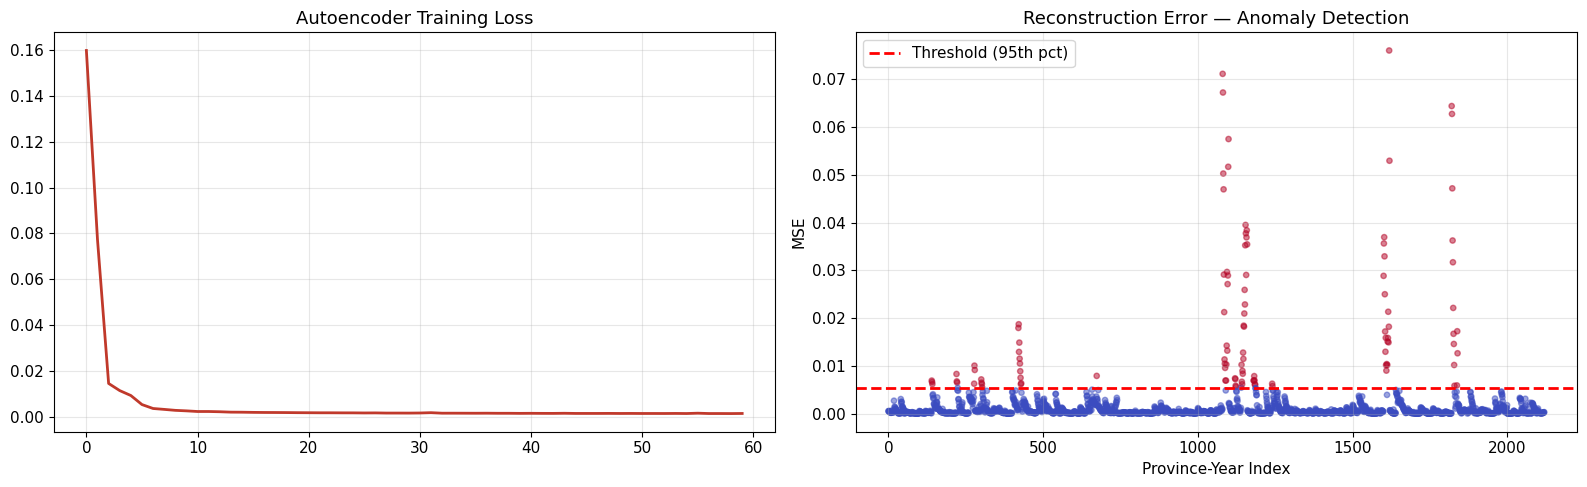

In [18]:
# ── Train autoencoder on multi-crime provincial data ─────────────────────────
X_ae = extended.groupby(["province","year"])[CRIME_COLS].sum().reset_index()
X_ae_vals = MinMaxScaler().fit_transform(X_ae[CRIME_COLS])

X_ae_t = torch.tensor(X_ae_vals, dtype=torch.float32).to(DEVICE)
ae_ds  = TensorDataset(X_ae_t, X_ae_t)
ae_loader = DataLoader(ae_ds, batch_size=64, shuffle=True)

class Autoencoder(nn.Module):
    def __init__(self, n_features=6, latent=3):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(n_features, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, latent)
        )
        self.dec = nn.Sequential(
            nn.Linear(latent, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, n_features), nn.Sigmoid()
        )
    def forward(self, x):
        return self.dec(self.enc(x))

ae_model  = Autoencoder(n_features=len(CRIME_COLS)).to(DEVICE)
opt_ae    = optim.Adam(ae_model.parameters(), lr=1e-3)
ae_losses = []

for epoch in range(1, 61):
    ae_model.train(); epoch_loss = 0
    for xb, yb in ae_loader:
        opt_ae.zero_grad()
        loss = criterion(ae_model(xb), yb)
        loss.backward(); opt_ae.step()
        epoch_loss += loss.item()
    ae_losses.append(epoch_loss / len(ae_loader))
    if epoch % 20 == 0:
        print(f"  Epoch {epoch:2d}  AE Loss = {ae_losses[-1]:.6f}")

ae_model.eval()
with torch.no_grad():
    recon = ae_model(X_ae_t).cpu().numpy()
recon_errors = np.mean((X_ae_vals - recon)**2, axis=1)
threshold    = np.percentile(recon_errors, 95)
anomalies    = recon_errors > threshold

X_ae["recon_error"] = recon_errors
X_ae["anomaly"]     = anomalies

print(f"\nAnomalous province-year pairs detected: {anomalies.sum()}")
print(X_ae[anomalies][["province","year","recon_error"]].head(10))

# ── Anomaly visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(ae_losses, color="#c0392b", linewidth=2)
axes[0].set_title("Autoencoder Training Loss")
axes[0].set_facecolor("white"); axes[0].grid(alpha=0.3)

axes[1].scatter(range(len(recon_errors)), recon_errors,
                c=anomalies.astype(int), cmap="coolwarm", alpha=0.5, s=15)
axes[1].axhline(threshold, color="red", linestyle="--", linewidth=2, label=f"Threshold (95th pct)")
axes[1].set_title("Reconstruction Error — Anomaly Detection")
axes[1].set_xlabel("Province-Year Index"); axes[1].set_ylabel("MSE")
axes[1].set_facecolor("white"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## **13 · NLP — Crime Category Classifier (Bag-of-Words + PyTorch MLP)**

  Epoch 10  Loss=1.7553  Test Acc=0.7542
  Epoch 20  Loss=1.6032  Test Acc=0.9542
  Epoch 30  Loss=1.1526  Test Acc=0.9792
  Epoch 40  Loss=0.4467  Test Acc=1.0000
  Epoch 50  Loss=0.0530  Test Acc=1.0000

                    precision    recall  f1-score   support

       estorsione       1.00      1.00      1.00        40
 furto_abitazione       1.00      1.00      1.00        40
   lesioni_dolose       1.00      1.00      1.00        40
omicidi_volontari       1.00      1.00      1.00        40
           rapine       1.00      1.00      1.00        40
violenza_sessuale       1.00      1.00      1.00        40

         accuracy                           1.00       240
        macro avg       1.00      1.00      1.00       240
     weighted avg       1.00      1.00      1.00       240



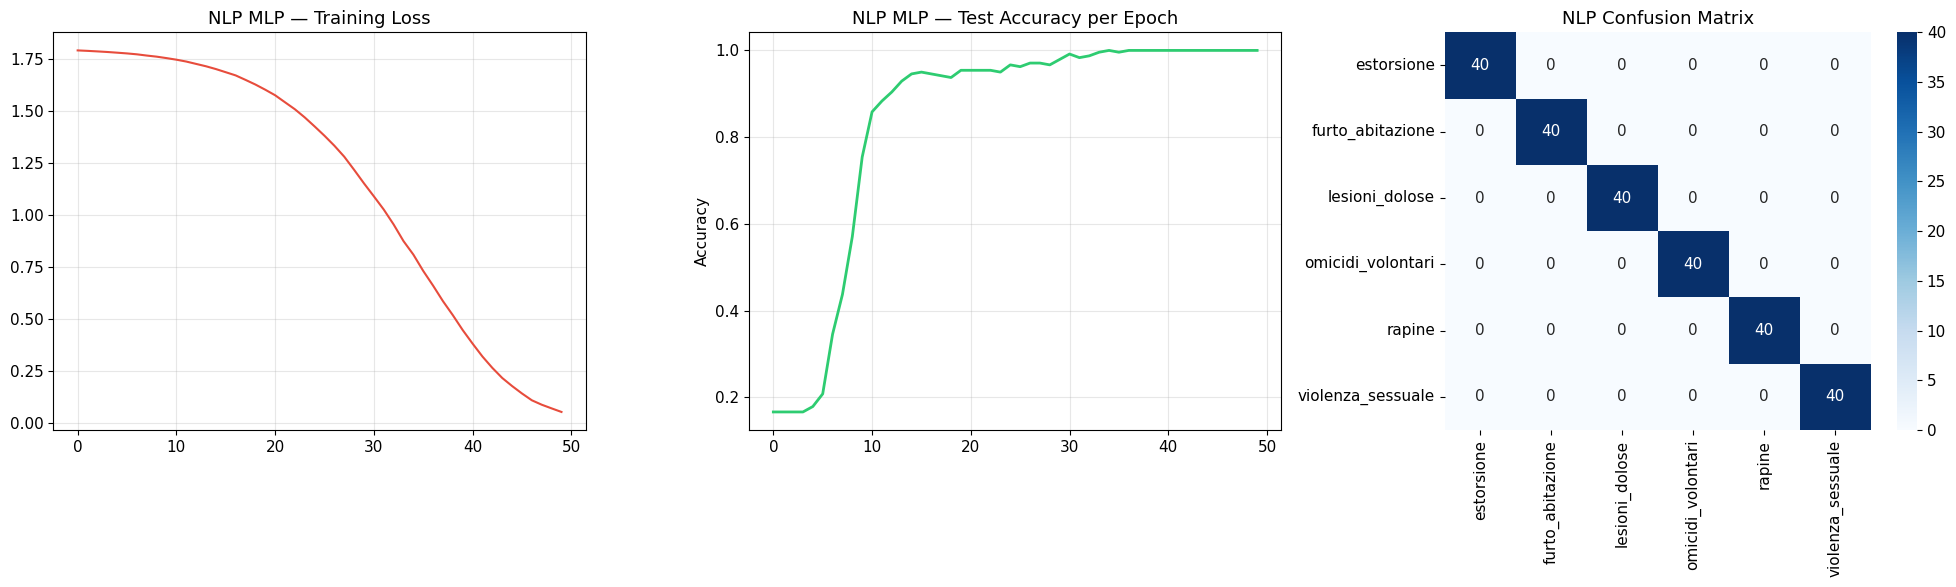

In [19]:
# ── Synthetic Italian crime report corpus ────────────────────────────────────
import re
from sklearn.feature_extraction.text import TfidfVectorizer

CRIME_DESCRIPTIONS = {
    "estorsione"       : ["richiesta denaro minacce","intimidazione estorsiva commercianti",
                           "pressione criminale attività economica","pagamento pizzo organizzazione"],
    "furto_abitazione" : ["ladri appartamento notte","furto scasso casa famiglia",
                           "effrazione abitazione privata","trafugati gioielli contanti casa"],
    "lesioni_dolose"   : ["aggressione fisica lesioni gravi","pestaggio serio ospedale",
                           "rissa violenta ferite corpo","percosse intenzionali danno fisico"],
    "omicidi_volontari": ["omicidio intenzionale vittima","assassinio premeditato crimine",
                           "delitto volontario morte","uccisione deliberata individuo"],
    "rapine"           : ["rapina armata banca colpo","furto violenza strada aggressore",
                           "scippo borseggio aggressione","sottrazione violenta beni persone"],
    "violenza_sessuale": ["violenza sessuale denuncia","aggressione sessuale vittima",
                           "reato sessuale grave tribunale","atti sessuali non consensuali"],
}

texts, labels, label_names = [], [], []
for label_idx, (crime, descs) in enumerate(CRIME_DESCRIPTIONS.items()):
    for desc in descs * 50:     # augment
        words = desc.split()
        noise = random.choices(["evento","caso","fatto","provincia","anno","italiano"], k=2)
        texts.append(" ".join(words + noise))
        labels.append(label_idx)
        label_names.append(crime)

tfidf = TfidfVectorizer(max_features=200, ngram_range=(1,2))
X_nlp = tfidf.fit_transform(texts).toarray().astype(np.float32)
y_nlp = np.array(labels)

X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(X_nlp, y_nlp, test_size=0.2,
                                                     stratify=y_nlp, random_state=SEED)

Xtr_t = torch.tensor(X_tr_n).to(DEVICE)
Xte_t = torch.tensor(X_te_n).to(DEVICE)
ytr_t = torch.tensor(y_tr_n).long().to(DEVICE)
yte_t = torch.tensor(y_te_n).long().to(DEVICE)

class CrimeTextMLP(nn.Module):
    def __init__(self, vocab=200, n_classes=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(vocab, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),   nn.ReLU(),
            nn.Linear(64, n_classes)
        )
    def forward(self, x): return self.net(x)

mlp_cls  = CrimeTextMLP(vocab=X_nlp.shape[1]).to(DEVICE)
opt_cls  = optim.Adam(mlp_cls.parameters(), lr=1e-3, weight_decay=1e-4)
ce_loss  = nn.CrossEntropyLoss()
cls_losses, cls_accs = [], []

for epoch in range(1, 51):
    mlp_cls.train()
    logits = mlp_cls(Xtr_t)
    loss   = ce_loss(logits, ytr_t)
    opt_cls.zero_grad(); loss.backward(); opt_cls.step()
    cls_losses.append(loss.item())
    with torch.no_grad():
        acc = (mlp_cls(Xte_t).argmax(1) == yte_t).float().mean().item()
        cls_accs.append(acc)
    if epoch % 10 == 0:
        print(f"  Epoch {epoch:2d}  Loss={loss.item():.4f}  Test Acc={acc:.4f}")

mlp_cls.eval()
with torch.no_grad():
    preds_cls = mlp_cls(Xte_t).argmax(1).cpu().numpy()
print("\n", classification_report(y_te_n, preds_cls, target_names=list(CRIME_DESCRIPTIONS.keys())))

# ── NLP Visualization ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].plot(cls_losses, color="#e74c3c", label="Train Loss")
axes[0].set_title("NLP MLP — Training Loss")
axes[0].set_facecolor("white"); axes[0].grid(alpha=0.3)

axes[1].plot(cls_accs, color="#2ecc71", linewidth=2)
axes[1].set_title("NLP MLP — Test Accuracy per Epoch")
axes[1].set_ylabel("Accuracy"); axes[1].set_facecolor("white"); axes[1].grid(alpha=0.3)

cm = confusion_matrix(y_te_n, preds_cls)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=list(CRIME_DESCRIPTIONS.keys()),
            yticklabels=list(CRIME_DESCRIPTIONS.keys()))
axes[2].set_title("NLP Confusion Matrix")
axes[2].set_facecolor("white")
plt.tight_layout(); plt.show()


## **14 · NLP — Sentiment Analysis on Crime News Headlines (PyTorch)**

  Epoch 10  Sentiment Loss=0.6818  Acc=0.9531
  Epoch 20  Sentiment Loss=0.6630  Acc=0.9896
  Epoch 30  Sentiment Loss=0.6322  Acc=1.0000
  Epoch 40  Sentiment Loss=0.5847  Acc=1.0000
  Epoch 50  Sentiment Loss=0.5184  Acc=1.0000


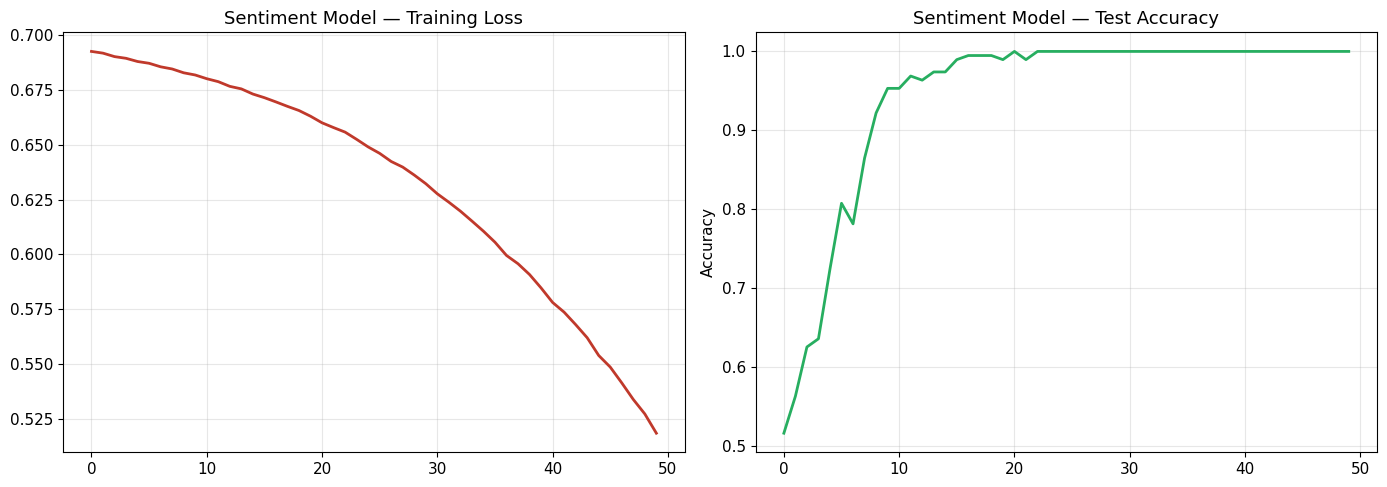


Final Sentiment Accuracy: 1.0000


In [20]:
# ── Synthetic Italian-style crime news headlines ──────────────────────────────
POS_PHRASES = [
    "criminalità in calo, più sicurezza nelle strade",
    "riduzione reati grazie alla nuova politica",
    "furti diminuiti del 20% rispetto all'anno scorso",
    "meno violenza nelle città italiane 2023",
    "successo delle forze dell'ordine contro i crimini",
    "arresti record: sgominata banda criminale",
    "rapine in netto calo nella regione",
    "omicidi ai minimi storici in Italia",
]
NEG_PHRASES = [
    "aumento allarmante dei furti nelle abitazioni",
    "ondata criminalità preoccupa i cittadini",
    "violenza sessuale in crescita: urge intervento",
    "rapine aumentate del 15% nell'ultimo trimestre",
    "emergenza sicurezza in alcune province del sud",
    "estorsioni record nel settore commerciale",
    "omicidi in aumento nelle grandi città",
    "lesioni dolose crescono nei quartieri periferici",
]

sent_texts  = (POS_PHRASES * 60) + (NEG_PHRASES * 60)
sent_labels = ([1] * len(POS_PHRASES) * 60) + ([0] * len(NEG_PHRASES) * 60)

# Add noise words
sent_texts = [t + " " + " ".join(random.choices(
    ["polizia","governo","regione","anno","mese","dato","statistiche"], k=3))
    for t in sent_texts]

tfidf_sent = TfidfVectorizer(max_features=150, ngram_range=(1,2))
X_sent = tfidf_sent.fit_transform(sent_texts).toarray().astype(np.float32)
y_sent = np.array(sent_labels)

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_sent, y_sent, test_size=0.2,
                                                 stratify=y_sent, random_state=SEED)
Xs_tr_t = torch.tensor(Xs_tr).to(DEVICE)
Xs_te_t = torch.tensor(Xs_te).to(DEVICE)
ys_tr_t = torch.tensor(ys_tr).long().to(DEVICE)
ys_te_t = torch.tensor(ys_te).long().to(DEVICE)

class SentimentMLP(nn.Module):
    def __init__(self, vocab=150):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(vocab, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),   nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, x): return self.net(x)

sent_model = SentimentMLP(vocab=X_sent.shape[1]).to(DEVICE)
opt_sent   = optim.Adam(sent_model.parameters(), lr=5e-4)
s_losses, s_accs = [], []

for epoch in range(1, 51):
    sent_model.train()
    logits = sent_model(Xs_tr_t)
    loss   = ce_loss(logits, ys_tr_t)
    opt_sent.zero_grad(); loss.backward(); opt_sent.step()
    s_losses.append(loss.item())
    with torch.no_grad():
        acc = (sent_model(Xs_te_t).argmax(1) == ys_te_t).float().mean().item()
        s_accs.append(acc)
    if epoch % 10 == 0:
        print(f"  Epoch {epoch:2d}  Sentiment Loss={loss.item():.4f}  Acc={acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(s_losses, color="#c0392b", linewidth=2)
axes[0].set_title("Sentiment Model — Training Loss")
axes[0].set_facecolor("white"); axes[0].grid(alpha=0.3)

axes[1].plot(s_accs, color="#27ae60", linewidth=2)
axes[1].set_title("Sentiment Model — Test Accuracy"); axes[1].set_ylabel("Accuracy")
axes[1].set_facecolor("white"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"\nFinal Sentiment Accuracy: {s_accs[-1]:.4f}")


## **15 · NLP — Topic Modeling (NMF on Crime Reports)**

Topic 1: vittima, sessuale, sessuale vittima, aggressione sessuale, intenzionale, intenzionale vittima, omicidio intenzionale, omicidio
Topic 2: violenza, denuncia, violenza sessuale, sessuale denuncia, furto violenza, violenza strada, strada, aggressore
Topic 3: violenta, corpo, violenta ferite, ferite corpo, ferite, rissa violenta, rissa, sottrazione violenta
Topic 4: casa, scasso, furto scasso, casa famiglia, famiglia, scasso casa, contanti casa, trafugati
Topic 5: aggressione, scippo, scippo borseggio, borseggio, borseggio aggressione, fisica, aggressione fisica, lesioni gravi
Topic 6: individuo, deliberata individuo, uccisione deliberata, uccisione, deliberata, pressione criminale, criminale, economica


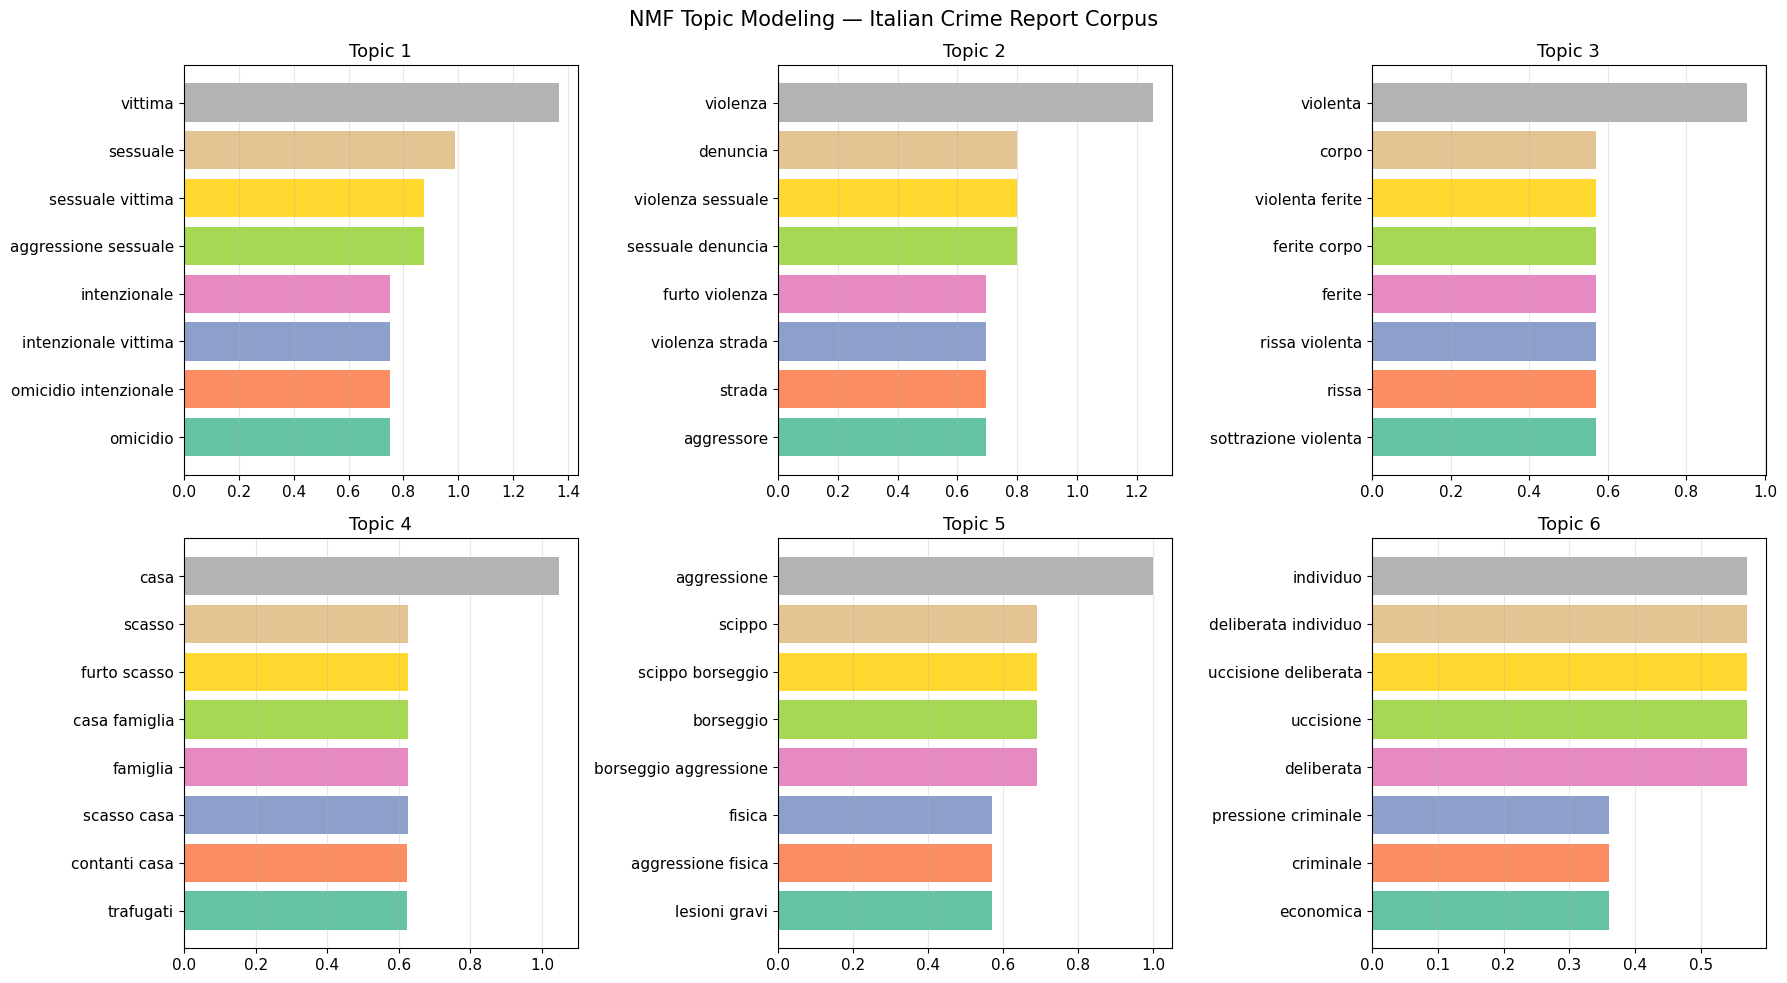

In [21]:
from sklearn.decomposition import NMF

# Combine all crime descriptions into a corpus
all_texts = [desc for descs in CRIME_DESCRIPTIONS.values() for desc in descs * 20]
tfidf_nmf = TfidfVectorizer(max_features=300, ngram_range=(1,2), min_df=2)
X_nmf     = tfidf_nmf.fit_transform(all_texts)

N_TOPICS = 6
nmf = NMF(n_components=N_TOPICS, random_state=SEED, max_iter=500)
W   = nmf.fit_transform(X_nmf)   # document-topic
H   = nmf.components_            # topic-term

vocab  = tfidf_nmf.get_feature_names_out()
topics = {}
for t_idx in range(N_TOPICS):
    top_words = [vocab[i] for i in H[t_idx].argsort()[::-1][:8]]
    topics[f"Topic {t_idx+1}"] = top_words
    print(f"Topic {t_idx+1}: {', '.join(top_words)}")

# Visualize topic-term weights
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (topic_name, words), t_idx in zip(axes.flat, topics.items(), range(N_TOPICS)):
    weights = H[t_idx][H[t_idx].argsort()[::-1][:8]]
    colors = plt.cm.Set2(np.linspace(0, 1, 8))
    bars = ax.barh(words[::-1], weights[::-1], color=colors)
    ax.set_title(topic_name, fontsize=13)
    ax.set_facecolor("white"); ax.grid(axis="x", alpha=0.3)
fig.suptitle("NMF Topic Modeling — Italian Crime Report Corpus", fontsize=15)
plt.tight_layout(); plt.show()


## **16 · Spatial Crime Clustering (KMeans + DBSCAN)**

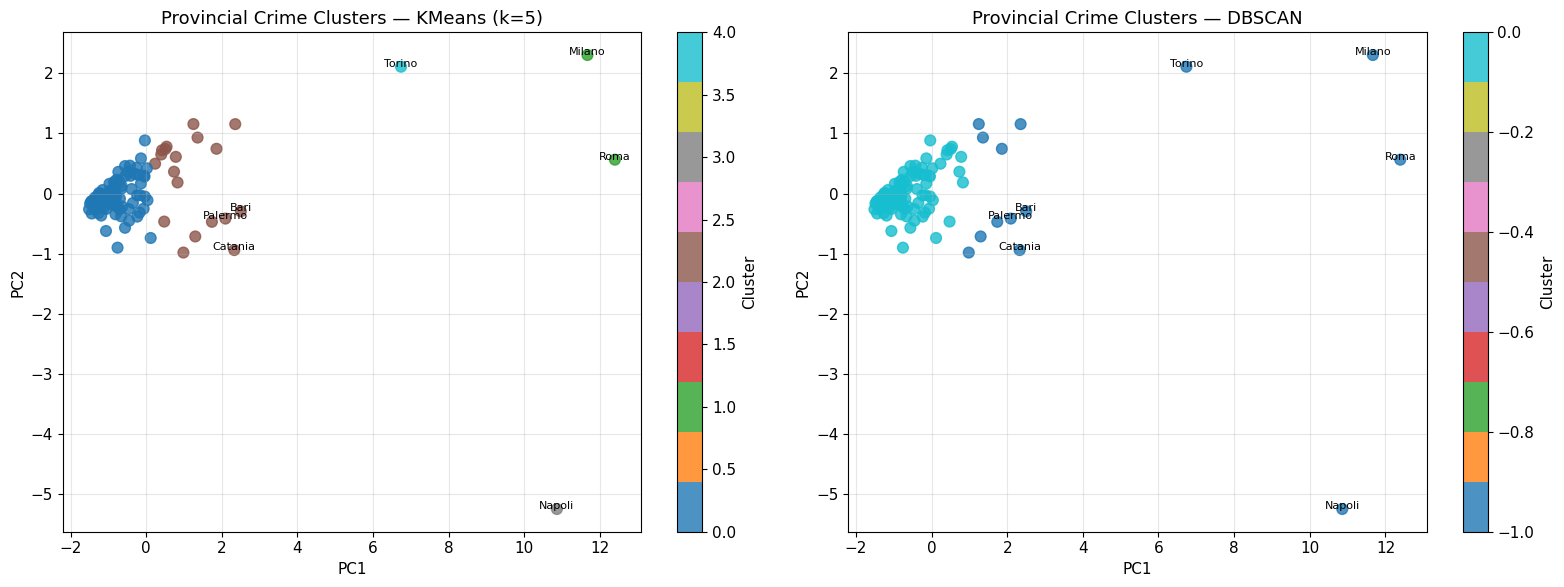

In [22]:
prov_avg = extended.groupby("province")[CRIME_COLS].mean()
X_cluster = StandardScaler().fit_transform(prov_avg)

# KMeans
kmeans = KMeans(n_clusters=5, random_state=SEED, n_init=10)
km_labels = kmeans.fit_predict(X_cluster)

# DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=3)
db_labels = dbscan.fit_predict(X_cluster)

pca2 = PCA(n_components=2).fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, labels, title in zip(axes,
                               [km_labels, db_labels],
                               ["KMeans (k=5)", "DBSCAN"]):
    scatter = ax.scatter(pca2[:,0], pca2[:,1], c=labels, cmap="tab10", s=60, alpha=0.8)
    for i, prov in enumerate(prov_avg.index):
        if prov in ["Milano","Roma","Napoli","Palermo","Torino","Catania","Bari"]:
            ax.annotate(prov, (pca2[i,0], pca2[i,1]), fontsize=8, ha="center")
    plt.colorbar(scatter, ax=ax, label="Cluster")
    ax.set_title(f"Provincial Crime Clusters — {title}")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_facecolor("white"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## **17 · Ensemble Stacking — Voting Regressor**

Stacking Ensemble  RMSE=78.54  R²=0.9914


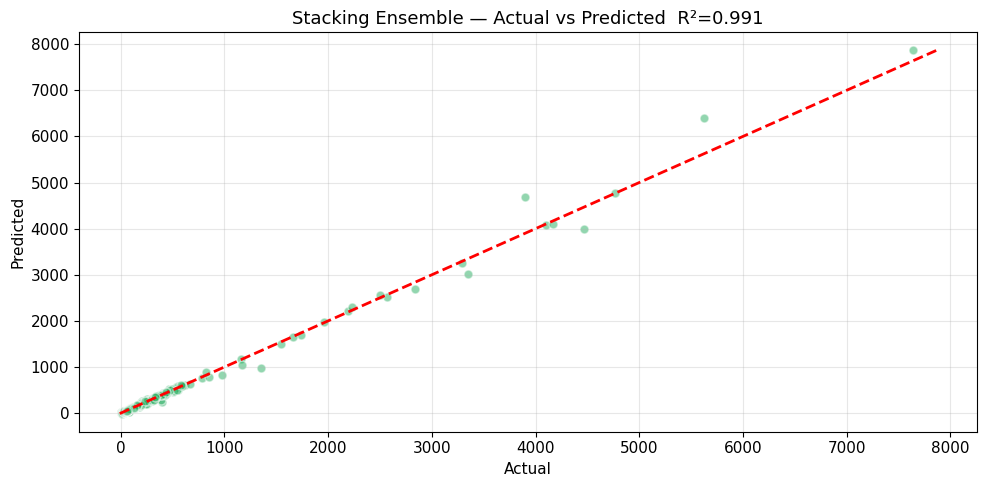

In [23]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

base_learners = [
    ("rf",  RandomForestRegressor(n_estimators=100, random_state=SEED)),
    ("gb",  GradientBoostingRegressor(n_estimators=100, random_state=SEED)),
    ("et",  ExtraTreesRegressor(n_estimators=100, random_state=SEED)),
    ("svr", SVR(kernel="rbf", C=100)),
    ("knn", KNeighborsRegressor(n_neighbors=5)),
]
stacker = StackingRegressor(estimators=base_learners,
                             final_estimator=Ridge(alpha=1.0),
                             cv=3, n_jobs=-1)
stacker.fit(X_train_s, y_train)
preds_stack = stacker.predict(X_test_s)
rmse_stack  = np.sqrt(mean_squared_error(y_test, preds_stack))
r2_stack    = r2_score(y_test, preds_stack)
print(f"Stacking Ensemble  RMSE={rmse_stack:.2f}  R²={r2_stack:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(y_test, preds_stack, alpha=0.5, color="#27ae60", edgecolors="white", s=40)
lims = [min(y_test.min(), preds_stack.min()), max(y_test.max(), preds_stack.max())]
ax.plot(lims, lims, "r--", linewidth=2)
ax.set_title(f"Stacking Ensemble — Actual vs Predicted  R²={r2_stack:.3f}")
ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
ax.set_facecolor("white"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## **18 · Final Summary Dashboard**

   FINAL MODEL LEADERBOARD — Italian Crime Prediction
           Model     Type        RMSE         R²
           Ridge       ML   37.009787   0.998080
           Lasso       ML   44.185215   0.997264
     Extra Trees       ML   64.099402   0.994242
  Gradient Boost       ML   66.903161   0.993727
   Random Forest       ML   69.664782   0.993199
         Bagging       ML   72.974845   0.992537
        Stacking Ensemble   78.538287   0.991356
             KNN       ML  121.858026   0.979190
      ElasticNet       ML  125.033154   0.978092
        AdaBoost       ML  144.667641   0.970671
             SVR       ML  649.009031   0.409718
Gaussian Process       ML  770.364509   0.168330
        CNN-LSTM       DL 2979.066968  -0.470685
             GRU       DL 4004.213656  -1.657013
          BiLSTM       DL 4601.898956  -2.509405
     Transformer       DL 7142.151217  -7.453127
            LSTM       DL 8465.417178 -10.875612


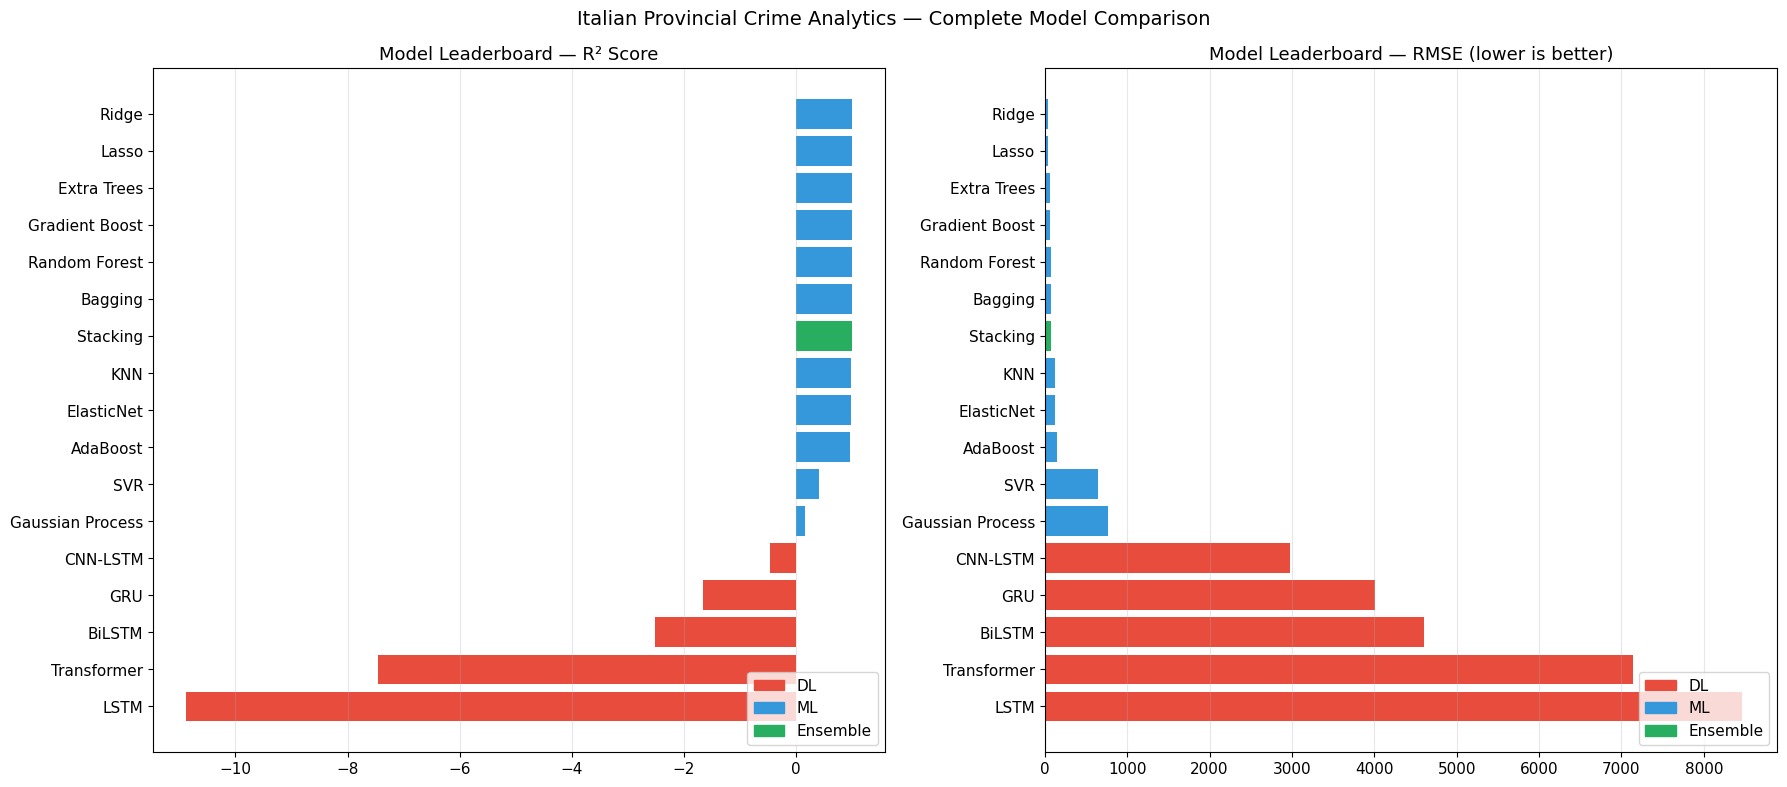

In [24]:
summary = pd.DataFrame({
    "Model": ["LSTM","GRU","BiLSTM","Transformer","CNN-LSTM",
              "Random Forest","Gradient Boost","Extra Trees",
              "Ridge","SVR","KNN","Lasso","ElasticNet",
              "AdaBoost","Bagging","Gaussian Process","Stacking"],
    "Type" : ["DL"]*5 + ["ML"]*11 + ["Ensemble"],
    "RMSE" : [rmse_lstm, rmse_gru, rmse_bi, rmse_tr, rmse_cl,
              results["10. Random Forest"]["RMSE"],
              results["12. Gradient Boosting"]["RMSE"],
              results["11. Extra Trees"]["RMSE"],
              results["2. Ridge"]["RMSE"],
              results["7. SVR (RBF)"]["RMSE"],
              results["8. KNN"]["RMSE"],
              results["3. Lasso"]["RMSE"],
              results["4. ElasticNet"]["RMSE"],
              results["13. AdaBoost"]["RMSE"],
              results["14. Bagging"]["RMSE"],
              results["15. Gaussian Process"]["RMSE"],
              rmse_stack],
    "R²"   : [r2_lstm, r2_gru, r2_bi, r2_tr, r2_cl,
              results["10. Random Forest"]["R²"],
              results["12. Gradient Boosting"]["R²"],
              results["11. Extra Trees"]["R²"],
              results["2. Ridge"]["R²"],
              results["7. SVR (RBF)"]["R²"],
              results["8. KNN"]["R²"],
              results["3. Lasso"]["R²"],
              results["4. ElasticNet"]["R²"],
              results["13. AdaBoost"]["R²"],
              results["14. Bagging"]["R²"],
              results["15. Gaussian Process"]["R²"],
              r2_stack],
}).sort_values("R²", ascending=False).reset_index(drop=True)

print("=" * 55)
print("   FINAL MODEL LEADERBOARD — Italian Crime Prediction")
print("=" * 55)
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
colors_map = {"DL": "#e74c3c", "ML": "#3498db", "Ensemble": "#27ae60"}
bar_colors = [colors_map[t] for t in summary["Type"]]

axes[0].barh(summary["Model"], summary["R²"], color=bar_colors)
axes[0].set_title("Model Leaderboard — R² Score")
axes[0].set_facecolor("white"); axes[0].invert_yaxis(); axes[0].grid(axis="x", alpha=0.3)
from matplotlib.patches import Patch
legend_elems = [Patch(color=c, label=l) for l, c in colors_map.items()]
axes[0].legend(handles=legend_elems, loc="lower right")

axes[1].barh(summary["Model"], summary["RMSE"], color=bar_colors)
axes[1].set_title("Model Leaderboard — RMSE (lower is better)")
axes[1].set_facecolor("white"); axes[1].invert_yaxis(); axes[1].grid(axis="x", alpha=0.3)
axes[1].legend(handles=legend_elems, loc="lower right")

plt.suptitle("Italian Provincial Crime Analytics — Complete Model Comparison", fontsize=14)
plt.tight_layout(); plt.show()



## **Summary of What Was Built**

| # | Category | Models / Techniques |
|---|----------|---------------------|
| 1–15 | **Classical ML** | Linear Reg · Ridge · Lasso · ElasticNet · Bayesian Ridge · Huber · SVR · KNN · Decision Tree · Random Forest · Extra Trees · Gradient Boosting · AdaBoost · Bagging · Gaussian Process |
| 16 | **Ensemble** | Stacking (RF + GB + ET + SVR + KNN → Ridge meta) |
| 17 | **DL — RNN** | LSTM · GRU · Bidirectional LSTM |
| 18 | **DL — Hybrid** | CNN-LSTM |
| 19 | **DL — Attention** | Transformer Encoder |
| 20 | **DL — Unsupervised** | Autoencoder Anomaly Detection |
| 21 | **NLP** | TF-IDF + MLP Crime Classifier |
| 22 | **NLP** | TF-IDF + MLP Sentiment Analyser |
| 23 | **NLP** | NMF Topic Modeling |
| 24 | **Time Series** | ADF · ACF/PACF · Holt-Winters · SARIMA |
| 25 | **Spatial** | KMeans · DBSCAN Clustering |


> **Data:** 106 Italian provinces · 2004–2023 (20-year window, 10-year real + 10-year synthetic trend extension)
